# **Coal_Price_Forecasting_and_Price_Optimization**

## **Table of Contents**

1. **Google Drive Mounting and Project Folder Setup**  
2. **Software Environment Setup and Library Imports**  
3. **Assignment Scope and Modelling Plan**  
4. **Load Raw Datasets and Initial Data Inspection**  
5. **Data Cleaning, Merging, and Master Dataset Preparation**  
6. **Exploratory Data Analysis (EDA)**  
7. **Data Processing and Feature Engineering**  
8. **Model Development and Evaluationg**  
9. **Model Comparison and Final Model Selection**  
10. **Forecasting Coal Prices for Jan 2026 to Jun 2026**



## **1. Google Drive Mounting and Project Folder Setup**

In [159]:
# 1.1 Mount Google Drive to access dataset and save outputs
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [160]:
# 1.2 All the Project paths

# Main Google Drive location
PROJECT_ROOT = Path("/content/drive/MyDrive")

# Raw/original downloaded market datasets
RAW_DATA_DIR = PROJECT_ROOT / "source_market_data"

# Cleaned and modelling-ready datasets created during the workflow
PREPARED_DATA_PATH = PROJECT_ROOT / "prepared_dataset"

# Model comparison tables, forecast results, price signals, and charts
FORECAST_OUTPUT_PATH = PROJECT_ROOT / "forecast_outputs"

# Create output folders if they do not already exist
PREPARED_DATA_PATH.mkdir(parents=True, exist_ok=True)
FORECAST_OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

print("Project paths are ready.")


Project paths are ready.


## **2. Software Environment Setup and Library Imports**

In [161]:
# 2.1 Basic Analysis and Reporting Libraries

# Data handling and numerical operations
import pandas as pd
import numpy as np

# Charts and notebook table display
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Utility support for dataset merging and general workflow
from functools import reduce
import warnings

# Keep notebook output readable during analysis
warnings.filterwarnings("ignore")

# Keep chart size consistent across the notebook
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

print("Basic analysis libraries imported successfully.")

Basic analysis libraries imported successfully.


In [162]:
# 2.2 Modelling, Tuning, and Evaluation Libraries

# Install modelling libraries used in this notebook
!pip install -q xgboost statsmodels tensorflow

# Time-series validation and parameter tuning
from sklearn.model_selection import TimeSeriesSplit, ParameterGrid

# Statistical time-series model with external market variables
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Boosting model used to capture non-linear relationships in engineered features
from xgboost import XGBRegressor

# TensorFlow is used through tf.keras for the LSTM model
import tensorflow as tf

# Forecast evaluation metrics used for model comparison
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

# Keep repeated model runs reasonably stable for comparison
np.random.seed(42)
tf.keras.utils.set_random_seed(42)

print("Modelling, tuning, and evaluation libraries are ready.")
print("TensorFlow version:", tf.__version__)

Modelling, tuning, and evaluation libraries are ready.
TensorFlow version: 2.20.0


## **3. Assignment Scope and Modelling Plan**

In [163]:
# 3.1 Assignment Scope and Modelling Plan

# Forecast horizon required for this project
FORECAST_START_DATE = "2026-01-01"
FORECAST_END_DATE = "2026-06-30"

# Models selected for comparison
MODELS_TO_COMPARE = ["XGBoost","SARIMAX"]

# Metrics used to evaluate forecast accuracy
EVALUATION_METRICS = ["MAE", "RMSE", "MAPE", "R2"]

print("Assignment scope and modelling plan are ready.")

Assignment scope and modelling plan are ready.


## **4. Load Raw Datasets & Initial Data Inspection**

This section loads all raw market datasets used for the coal price forecasting assignment and performs an initial inspection before cleaning.

The objective here is not to modify the data. Instead, the purpose is to understand the raw structure, confirm that the datasets are loaded correctly, and review the first-level shape and sample records before moving into cleaning and preparation.

In [164]:
# 4.1 Raw market data files used in the forecasting workflow

raw_file_map = {
    "newcastle_coal": "Newcastle Coal Futures Historical Data.csv",
    "brent_oil": "Brent Oil Futures Historical Data.csv",
    "natural_gas": "Natural Gas Futures Historical Data.csv",
    "usd_index": "US Dollar Index Historical Data.csv",
    "baltic_dry_index": "Baltic Dry Index Historical Data.csv",
    "aud_usd": "AUD_USD Historical Data.csv",
    "carbon_emissions": "Carbon Emissions Futures Historical Data.csv",
    "jkm_lng": "LNG Japan_Korea Marker PLATTS Future Historical Data.csv",
    "iron_ore": "Iron ore fines 62% Fe CFR Futures Historical Data.csv"
}

In [165]:
# 4.2 Load all raw CSV files

raw_datasets = {}

for name, file_name in raw_file_map.items():
    raw_datasets[name] = pd.read_csv(RAW_DATA_DIR / file_name)

print("Raw datasets loaded successfully.")
print("Total datasets:", len(raw_datasets))

print("All raw datasets loaded successfully.")

Raw datasets loaded successfully.
Total datasets: 9
All raw datasets loaded successfully.


In [166]:
# 4.3 Check number of rows and columns in each dataset

for name, df in raw_datasets.items():
    print(name, ":", df.shape)

newcastle_coal : (2955, 7)
brent_oil : (2960, 7)
natural_gas : (3016, 7)
usd_index : (2983, 7)
baltic_dry_index : (2853, 7)
aud_usd : (2993, 7)
carbon_emissions : (2946, 7)
jkm_lng : (2877, 7)
iron_ore : (2883, 7)


In [167]:
# 4.4 Preview first rows of each dataset

for dataset_name, df in raw_datasets.items():
    print(dataset_name)
    print("-" * 70)
    display(df.head())

newcastle_coal
----------------------------------------------------------------------


,Date,Price,Open,High,Low,Vol.,Change %
0,06/19/2026,144.00,144.00,144.00,144.00,0.02K,0.00%
1,06/18/2026,144.00,144.00,144.00,144.00,0.03K,0.14%
2,06/17/2026,143.80,144.50,144.50,144.50,0.00K,-0.83%
3,06/16/2026,145.00,145.50,145.50,145.50,0.02K,-0.92%
4,06/15/2026,146.35,146.35,146.35,146.35,0.01K,-1.71%


brent_oil
----------------------------------------------------------------------


,Date,Price,Open,High,Low,Vol.,Change %
0,06/19/2026,80.57,79.20,80.81,78.77,160.71K,0.90%
1,06/18/2026,79.85,78.85,80.05,76.54,287.54K,0.38%
2,06/17/2026,79.55,79.41,82.97,77.75,283.45K,0.75%
3,06/16/2026,78.96,83.80,83.80,78.45,367.01K,-5.06%
4,06/15/2026,83.17,85.00,85.93,82.40,284.06K,-4.76%


natural_gas
----------------------------------------------------------------------


...

,Date,Price,Open,High,Low,Vol.,Change %
0,06/19/2026,79.53,78.44,79.61,78.20,1.79K,0.73%
1,06/18/2026,78.95,78.97,79.51,78.60,0.71K,0.27%
2,06/17/2026,78.74,79.29,79.82,78.49,0.45K,-0.09%
3,06/16/2026,78.81,79.00,79.30,78.10,1.14K,-0.23%
4,06/15/2026,78.99,77.15,78.93,76.74,0.96K,3.73%


jkm_lng
----------------------------------------------------------------------


,Date,Price,Open,High,Low,Vol.,Change %
0,06/18/2026,15.315,15.315,15.315,15.315,NaN,-3.19%
1,06/17/2026,15.820,15.820,15.820,15.820,NaN,-0.75%
2,06/16/2026,15.940,15.940,15.940,15.940,NaN,-15.14%
3,06/15/2026,18.783,18.783,18.783,18.783,NaN,-0.38%
4,06/12/2026,18.855,18.855,18.855,18.855,NaN,-0.34%


iron_ore
----------------------------------------------------------------------


,Date,Price,Open,High,Low,Vol.,Change %
0,06/18/2026,101.14,101.14,101.14,101.14,NaN,-0.14%
1,06/17/2026,101.28,101.28,101.28,101.28,NaN,-0.37%
2,06/16/2026,101.66,101.66,101.66,101.66,NaN,-0.27%
3,06/15/2026,101.94,101.94,101.94,101.94,NaN,0.31%
4,06/12/2026,101.62,101.62,101.62,101.62,NaN,0.02%


In [168]:
# 4.5 Check data types before cleaning

for dataset_name, df in raw_datasets.items():
    print("\n" + "-" * 70)
    print(dataset_name)
    print("-" * 70)
    print(df.dtypes)


----------------------------------------------------------------------
newcastle_coal
----------------------------------------------------------------------
Date         object
Price       float64
Open        float64
High        float64
Low         float64
Vol.         object
Change %     object
dtype: object

----------------------------------------------------------------------
brent_oil
----------------------------------------------------------------------
Date         object
Price       float64
Open        float64
High        float64
Low         float64
Vol.         object
Change %     object
dtype: object

----------------------------------------------------------------------
natural_gas
----------------------------------------------------------------------
Date         object
Price       float64
Open        float64
High        float64
Low         float64
Vol.         object
Change %     object
dtype: object

----------------------------------------------------------------------


In [169]:
# 4.6 Check missing values before cleaning

for name, df in raw_datasets.items():
    print("\n", name)
    print(df.isnull().sum())





 newcastle_coal
Date          0
Price         0
Open          0
High          0
Low           0
Vol.        670
Change %      0
dtype: int64

 brent_oil
Date        0
Price       0
Open        0
High        0
Low         0
Vol.        1
Change %    0
dtype: int64

 natural_gas
Date          0
Price         0
Open          0
High          0
Low           0
Vol.        126
Change %      0
dtype: int64

 usd_index
Date           0
Price          0
Open           0
High           0
Low            0
Vol.        2843
Change %       0
dtype: int64

 baltic_dry_index
Date           0
Price          0
Open           0
High           0
Low            0
Vol.        2853
Change %       0
dtype: int64

 aud_usd
Date           0
Price          0
Open           0
High           0
Low            0
Vol.        2993
Change %       0
dtype: int64

 carbon_emissions
Date        0
Price       0
Open        0
High        0
Low         0
Vol.        9
Change %    0
dtype: int64

 jkm_lng
Date           0
Pr

In [170]:
#4.7 Check date coverage for each dataset

for name, df in raw_datasets.items():
    dates = pd.to_datetime(df["Date"], errors="coerce")

    print("\n", name)
    print("Start date:", dates.min())
    print("End date:", dates.max())


 newcastle_coal
Start date: 2015-01-02 00:00:00
End date: 2026-06-19 00:00:00

 brent_oil
Start date: 2015-01-02 00:00:00
End date: 2026-06-19 00:00:00

 natural_gas
Start date: 2015-01-01 00:00:00
End date: 2026-06-19 00:00:00

 usd_index
Start date: 2015-01-01 00:00:00
End date: 2026-06-19 00:00:00

 baltic_dry_index
Start date: 2015-01-02 00:00:00
End date: 2026-06-19 00:00:00

 aud_usd
Start date: 2015-01-01 00:00:00
End date: 2026-06-19 00:00:00

 carbon_emissions
Start date: 2015-01-02 00:00:00
End date: 2026-06-19 00:00:00

 jkm_lng
Start date: 2015-01-02 00:00:00
End date: 2026-06-18 00:00:00

 iron_ore
Start date: 2015-01-02 00:00:00
End date: 2026-06-18 00:00:00


In [171]:
# 4.8 Check key column missing values and duplicate dates before merging

required_column_check = []

for name, df in raw_datasets.items():
    required_column_check.append({
        "dataset_name": name,
        "date_missing": df["Date"].isnull().sum(),
        "price_missing": df["Price"].isnull().sum(),
        "duplicate_date_records": df["Date"].duplicated().sum()
    })

required_column_check_df = pd.DataFrame(required_column_check)

required_column_check_df

,dataset_name,date_missing,price_missing,duplicate_date_records
0,newcastle_coal,0,0,0
1,brent_oil,0,0,0
2,natural_gas,0,0,0
3,usd_index,0,0,0
4,baltic_dry_index,0,0,0
5,aud_usd,0,0,0
6,carbon_emissions,0,0,0
7,jkm_lng,0,0,0
8,iron_ore,0,0,0


## **5. Data Cleaning, Merging & Master Dataset Preparation**

In this section, I clean the raw market datasets and prepare one master dataset for EDA and modelling. The main cleaning decision is to remove the Vol. column because it has high missing values, while keeping Date, Price, Open, High, Low, and Change %.

In [172]:
# 5.1 Columns kept for analysis
# Volume is removed because it has high missing values and is not used in this model

columns_to_keep = ["Date", "Price", "Open", "High", "Low", "Change %"]

In [173]:
# 5.2 Keep selected columns from each dataset
# Volume is not included because it has many missing values a

cleaned_datasets = {}

for name, df in raw_datasets.items():
    cleaned_datasets[name] = df[columns_to_keep].copy()

print("Required columns selected from all datasets.")

Required columns selected from all datasets.


In [174]:
# 5.3 Convert Date and market value columns into usable format

for name, df in cleaned_datasets.items():
    df["Date"] = pd.to_datetime(df["Date"])

    df["Price"] = pd.to_numeric(df["Price"].replace(",", "", regex=True))
    df["Open"] = pd.to_numeric(df["Open"].replace(",", "", regex=True))
    df["High"] = pd.to_numeric(df["High"].replace(",", "", regex=True))
    df["Low"] = pd.to_numeric(df["Low"].replace(",", "", regex=True))
    df["Change %"] = pd.to_numeric(df["Change %"].replace("%", "", regex=True))

print("Date and numeric columns converted.")

Date and numeric columns converted.


In [175]:
# 5.4 Rename columns using dataset name so they stay clear after merging

for name, df in cleaned_datasets.items():
    df.columns = [
        "Date",
        f"{name}_price",
        f"{name}_open",
        f"{name}_high",
        f"{name}_low",
        f"{name}_change_pct"
    ]

print("Columns renamed using dataset names.")

Columns renamed using dataset names.


In [176]:
# 5.5 Check renamed columns for each cleaned dataset

for name, df in cleaned_datasets.items():
    print("\n", name)
    print(df.columns.tolist())


 newcastle_coal
['Date', 'newcastle_coal_price', 'newcastle_coal_open', 'newcastle_coal_high', 'newcastle_coal_low', 'newcastle_coal_change_pct']

 brent_oil
['Date', 'brent_oil_price', 'brent_oil_open', 'brent_oil_high', 'brent_oil_low', 'brent_oil_change_pct']

 natural_gas
['Date', 'natural_gas_price', 'natural_gas_open', 'natural_gas_high', 'natural_gas_low', 'natural_gas_change_pct']

 usd_index
['Date', 'usd_index_price', 'usd_index_open', 'usd_index_high', 'usd_index_low', 'usd_index_change_pct']

 baltic_dry_index
['Date', 'baltic_dry_index_price', 'baltic_dry_index_open', 'baltic_dry_index_high', 'baltic_dry_index_low', 'baltic_dry_index_change_pct']

 aud_usd
['Date', 'aud_usd_price', 'aud_usd_open', 'aud_usd_high', 'aud_usd_low', 'aud_usd_change_pct']

 carbon_emissions
['Date', 'carbon_emissions_price', 'carbon_emissions_open', 'carbon_emissions_high', 'carbon_emissions_low', 'carbon_emissions_change_pct']

 jkm_lng
['Date', 'jkm_lng_price', 'jkm_lng_open', 'jkm_lng_high',

In [177]:
# 5.6 Merge all cleaned datasets using Date.
# Newcastle coal is the target variable, so it is used as the base dataset.

master_df = cleaned_datasets["newcastle_coal"].copy()

master_df = master_df.merge(cleaned_datasets["brent_oil"], on="Date", how="left")
master_df = master_df.merge(cleaned_datasets["natural_gas"], on="Date", how="left")
master_df = master_df.merge(cleaned_datasets["usd_index"], on="Date", how="left")
master_df = master_df.merge(cleaned_datasets["baltic_dry_index"], on="Date", how="left")
master_df = master_df.merge(cleaned_datasets["aud_usd"], on="Date", how="left")
master_df = master_df.merge(cleaned_datasets["carbon_emissions"], on="Date", how="left")
master_df = master_df.merge(cleaned_datasets["jkm_lng"], on="Date", how="left")
master_df = master_df.merge(cleaned_datasets["iron_ore"], on="Date", how="left")

print("Master dataset created successfully.")
print("Shape:", master_df.shape)

master_df.head()

Master dataset created successfully.
Shape: (2955, 46)


,Date,newcastle_coal_price,newcastle_coal_open,newcastle_coal_high,newcastle_coal_low,newcastle_coal_change_pct,brent_oil_price,brent_oil_open,brent_oil_high,brent_oil_low,...,jkm_lng_price,jkm_lng_open,jkm_lng_high,jkm_lng_low,jkm_lng_change_pct,iron_ore_price,iron_ore_open,iron_ore_high,iron_ore_low,iron_ore_change_pct
0,2026-06-19,144.00,144.00,144.00,144.00,0.00,80.57,79.20,80.81,78.77,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-06-18,144.00,144.00,144.00,144.00,0.14,79.85,78.85,80.05,76.54,...,15.315,15.315,15.315,15.315,-3.19,101.14,101.14,101.14,101.14,-0.14
2,2026-06-17,143.80,144.50,144.50,144.50,-0.83,79.55,79.41,82.97,77.75,...,15.820,15.820,15.820,15.820,-0.75,101.28,101.28,101.28,101.28,-0.37
3,2026-06-16,145.00,145.50,145.50,145.50,-0.92,78.96,83.80,83.80,78.45,...,15.940,15.940,15.940,15.940,-15.14,101.66,101.66,101.66,101.66,-0.27
4,2026-06-15,146.35,146.35,146.35,146.35,-1.71,83.17,85.00,85.93,82.40,...,18.783,18.783,18.783,18.783,-0.38,101.94,101.94,101.94,101.94,0.31


In [178]:
# 5.7 Check merged master dataset after joining all variables

master_df = master_df.sort_values("Date")

print("Shape:", master_df.shape)
print("Start date:", master_df["Date"].min())
print("End date:", master_df["Date"].max())
print("Duplicate dates:", master_df["Date"].duplicated().sum())

master_df.isnull().sum()

Shape: (2955, 46)
Start date: 2015-01-02 00:00:00
End date: 2026-06-19 00:00:00
Duplicate dates: 0


,0
Date,0
newcastle_coal_price,0
newcastle_coal_open,0
newcastle_coal_high,0
newcastle_coal_low,0
newcastle_coal_change_pct,0
brent_oil_price,0
brent_oil_open,0
brent_oil_high,0
brent_oil_low,0


In [179]:
# 5.8 Fill small gaps created after merging different market datasets.
# This is common because all markets do not trade on the same dates.

master_df = master_df.sort_values("Date")
master_df = master_df.ffill()

print("Missing values filled using forward fill.")

Missing values filled using forward fill.


In [180]:
# Check if any missing values are still left after forward fill

master_df.isnull().sum()

,0
Date,0
newcastle_coal_price,0
newcastle_coal_open,0
newcastle_coal_high,0
newcastle_coal_low,0
newcastle_coal_change_pct,0
brent_oil_price,0
brent_oil_open,0
brent_oil_high,0
brent_oil_low,0


In [181]:
# 5.9 Final quality check before EDA

print("Final shape:", master_df.shape)
print("Start date:", master_df["Date"].min())
print("End date:", master_df["Date"].max())
print("Duplicate dates:", master_df["Date"].duplicated().sum())

master_df.head()

Final shape: (2955, 46)
Start date: 2015-01-02 00:00:00
End date: 2026-06-19 00:00:00
Duplicate dates: 0


,Date,newcastle_coal_price,newcastle_coal_open,newcastle_coal_high,newcastle_coal_low,newcastle_coal_change_pct,brent_oil_price,brent_oil_open,brent_oil_high,brent_oil_low,...,jkm_lng_price,jkm_lng_open,jkm_lng_high,jkm_lng_low,jkm_lng_change_pct,iron_ore_price,iron_ore_open,iron_ore_high,iron_ore_low,iron_ore_change_pct
2954,2015-01-02,61.30,61.30,61.30,61.30,-1.61,56.42,58.02,58.54,55.48,...,10.055,10.055,10.055,10.055,0.0,70.06,70.06,70.06,70.06,1.65
2953,2015-01-05,61.25,61.25,61.25,61.25,-0.08,53.11,56.25,56.30,52.66,...,10.005,10.005,10.005,10.005,-0.5,69.98,69.98,69.98,69.98,-0.11
2952,2015-01-06,61.45,61.45,61.45,61.45,0.33,51.10,53.20,53.60,50.52,...,9.985,9.985,9.985,9.985,-0.2,71.57,71.57,71.57,71.57,2.27
2951,2015-01-07,60.60,60.60,60.60,60.60,-1.38,51.15,51.15,51.84,49.66,...,9.985,9.985,9.985,9.985,0.0,71.24,71.24,71.24,71.24,-0.46
2950,2015-01-08,60.60,60.60,60.60,60.60,0.00,50.96,51.06,51.91,49.81,...,9.975,9.975,9.975,9.975,-0.1,70.95,70.95,70.95,70.95,-0.41


In [182]:
# 5.10 Save the cleaned master dataset for EDA and modelling

master_df.to_csv(PREPARED_DATA_PATH / "cleaned_master_dataset.csv", index=False)

print("Cleaned master dataset saved successfully.")

Cleaned master dataset saved successfully.


## **6. Exploratory Data Analysis (EDA)**
The objective of this EDA section is to understand the historical behaviour of Newcastle coal prices and the key market variables that may influence coal price movement.

In this section, we focus on:

- Understanding the long-term movement of Newcastle coal prices
- Reviewing the behaviour of important market drivers such as crude oil, natural gas, USD index, freight rates, LNG, carbon emissions, iron ore, and AUD/USD
- Checking correlation between coal prices and independent variables
- Identifying early signs of trend, volatility, seasonality, and abnormal market movements

This step is important before feature engineering and model development because it helps us understand which variables are likely to carry useful forecasting signals.

In [183]:
# 6. 1 Create a separate EDA copy from the cleaned master dataset.
# This keeps master_df unchanged for the next data processing and feature engineering stage.
eda_df = master_df.copy()

# Keep the data in proper time order before plotting trends and correlations.
eda_df['Date'] = pd.to_datetime(eda_df['Date'])
eda_df = eda_df.sort_values('Date').reset_index(drop=True)

print("EDA dataframe is ready.")
print("Rows:", eda_df.shape[0])
print("Columns:", eda_df.shape[1])

EDA dataframe is ready.
Rows: 2955
Columns: 46


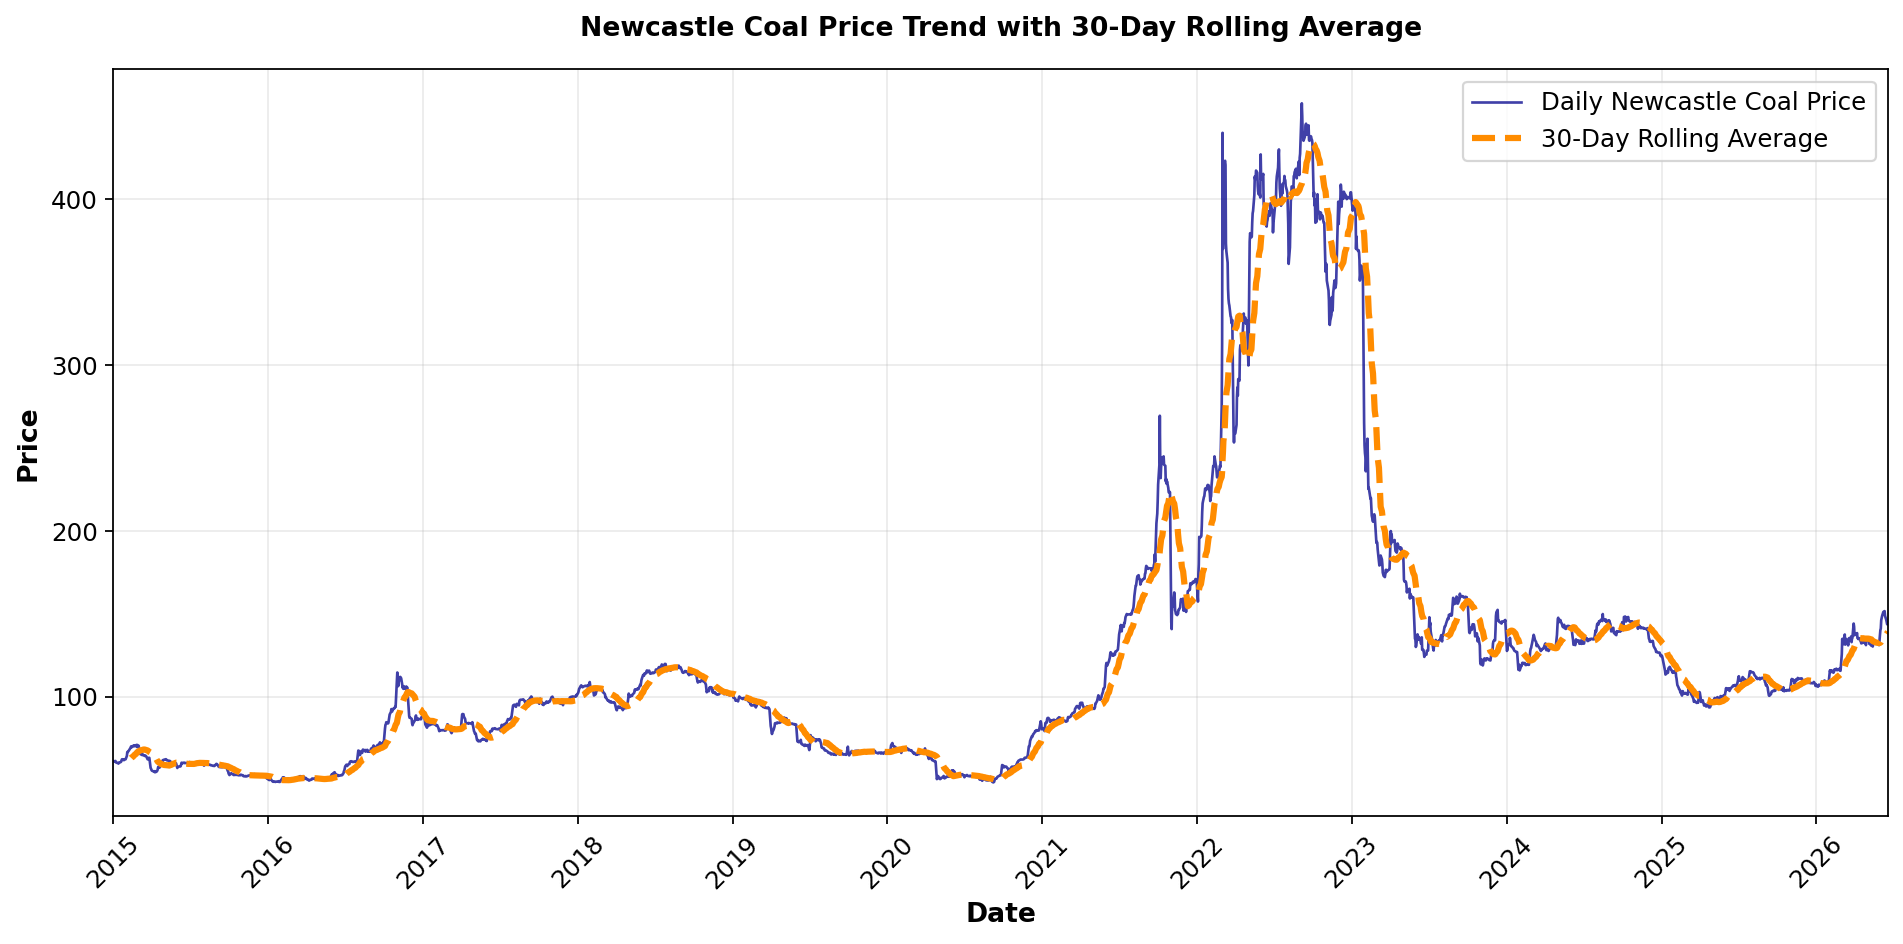

In [184]:
# 6.2 Analyze Newcastle Coal Price Trend

# Newcastle coal price is the target variable we want to forecast.
target_col = "newcastle_coal_price"

# Create a 30-day rolling average of Newcastle coal price
# Since our data is daily, 30 days gives us an approximate monthly trend
# This does not change the original coal price column; it only creates a smoother line for visual analysis.
eda_df["coal_rolling_30d"] = eda_df[target_col].rolling(window=30).mean()

# Set a larger figure size and higher resolution so the chart is clear for reports
plt.figure(figsize=(12, 6), dpi=160)

# Plot the actual daily Newcastle coal price.
# This line shows the real day-to-day price movement in the market.
plt.plot(
    eda_df["Date"],
    eda_df[target_col],
    color="darkblue",
    linewidth=1.2,
    alpha=0.75,
    linestyle="-",
    label="Daily Newcastle Coal Price"
)

# Plot the 30-day rolling average.
# This smoother line helps us understand the broader monthly direction of coal prices.
plt.plot(
    eda_df["Date"],
    eda_df["coal_rolling_30d"],
    color="darkorange",
    linewidth=2.8,
    linestyle="--",
    label="30-Day Rolling Average"
)

# Add a clear chart title for presentation/reporting purpose.
plt.title(
    "Newcastle Coal Price Trend with 30-Day Rolling Average",
    fontsize=12,
    fontweight="bold",
    pad=15
)

# Add axis labels so the chart is easy to understand.
plt.xlabel("Date", fontsize=12, fontweight="bold")
plt.ylabel("Price", fontsize=12, fontweight="bold")

# Get the first and last year from the dataset.
# This helps us show the full timeline properly on the x-axis.
start_year = eda_df["Date"].dt.year.min()
end_year = eda_df["Date"].dt.year.max()

# Create yearly tick marks from the first year to the last year.
# This ensures that the chart displays each year clearly, including the starting year.
year_ticks = pd.date_range(
    start=f"{start_year}-01-01",
    end=f"{end_year}-12-31",
    freq="YS"
)

# Apply the yearly labels on the x-axis.
plt.xticks(
    ticks=year_ticks,
    labels=[str(year.year) for year in year_ticks],
    rotation=45,
    fontsize=11
)

# Force the chart to start from the first available year in the dataset.
plt.xlim(pd.Timestamp(f"{start_year}-01-01"), eda_df["Date"].max())

# Improve y-axis readability.
plt.yticks(fontsize=11)

# Add a light grid to make the trend easier to read without making the chart crowded.
plt.grid(True, alpha=0.25)

# Show the legend so both lines are clearly identified.
plt.legend(fontsize=11, frameon=True)

# Adjust spacing so labels and title do not overlap.
plt.tight_layout()

# Display the final chart.
plt.show()

Market price variables selected for EDA trend analysis:
- brent_oil_price
- natural_gas_price
- usd_index_price
- baltic_dry_index_price
- aud_usd_price
- carbon_emissions_price
- jkm_lng_price
- iron_ore_price

Total market variables selected: 8


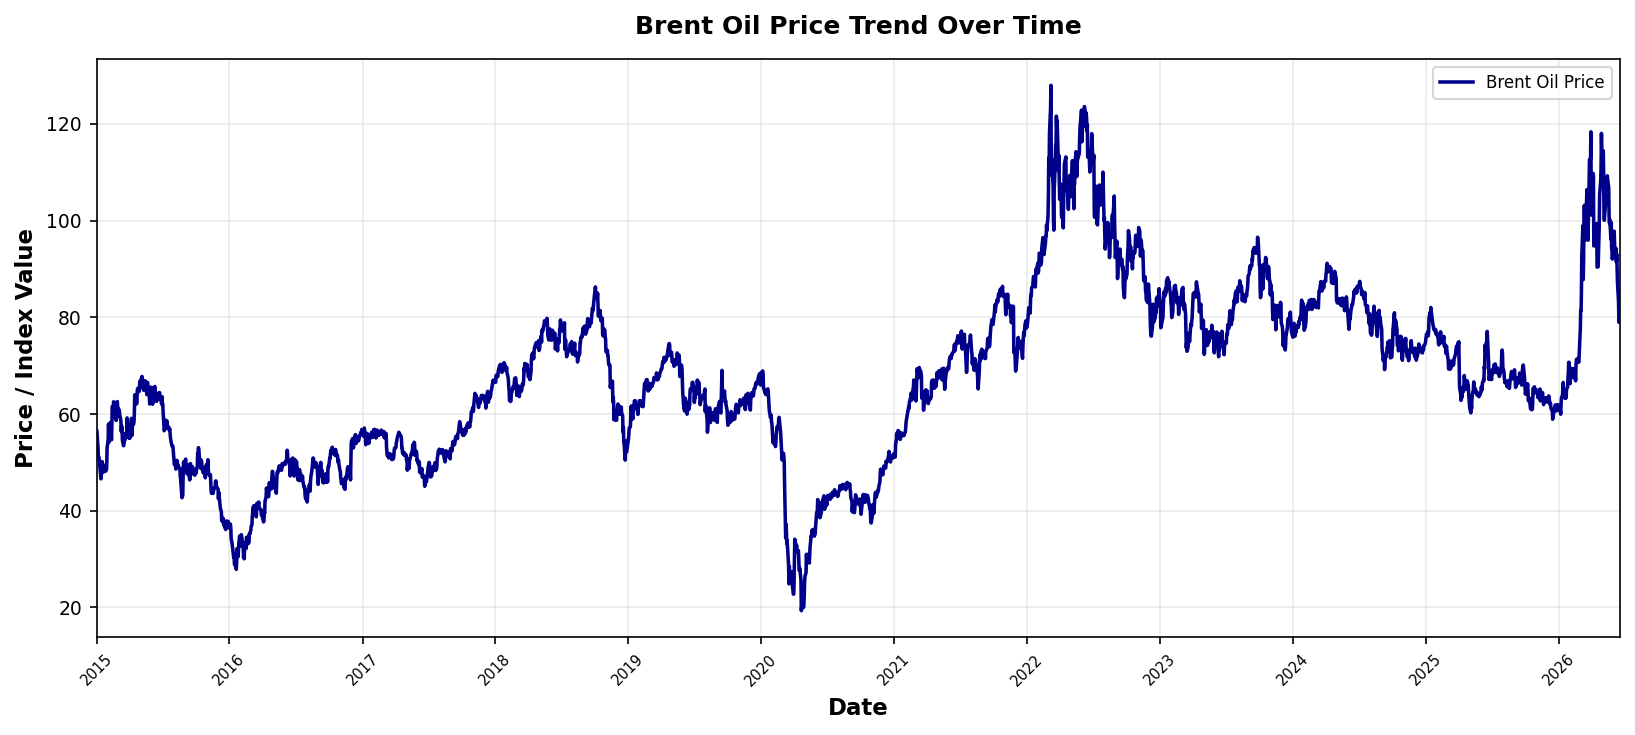

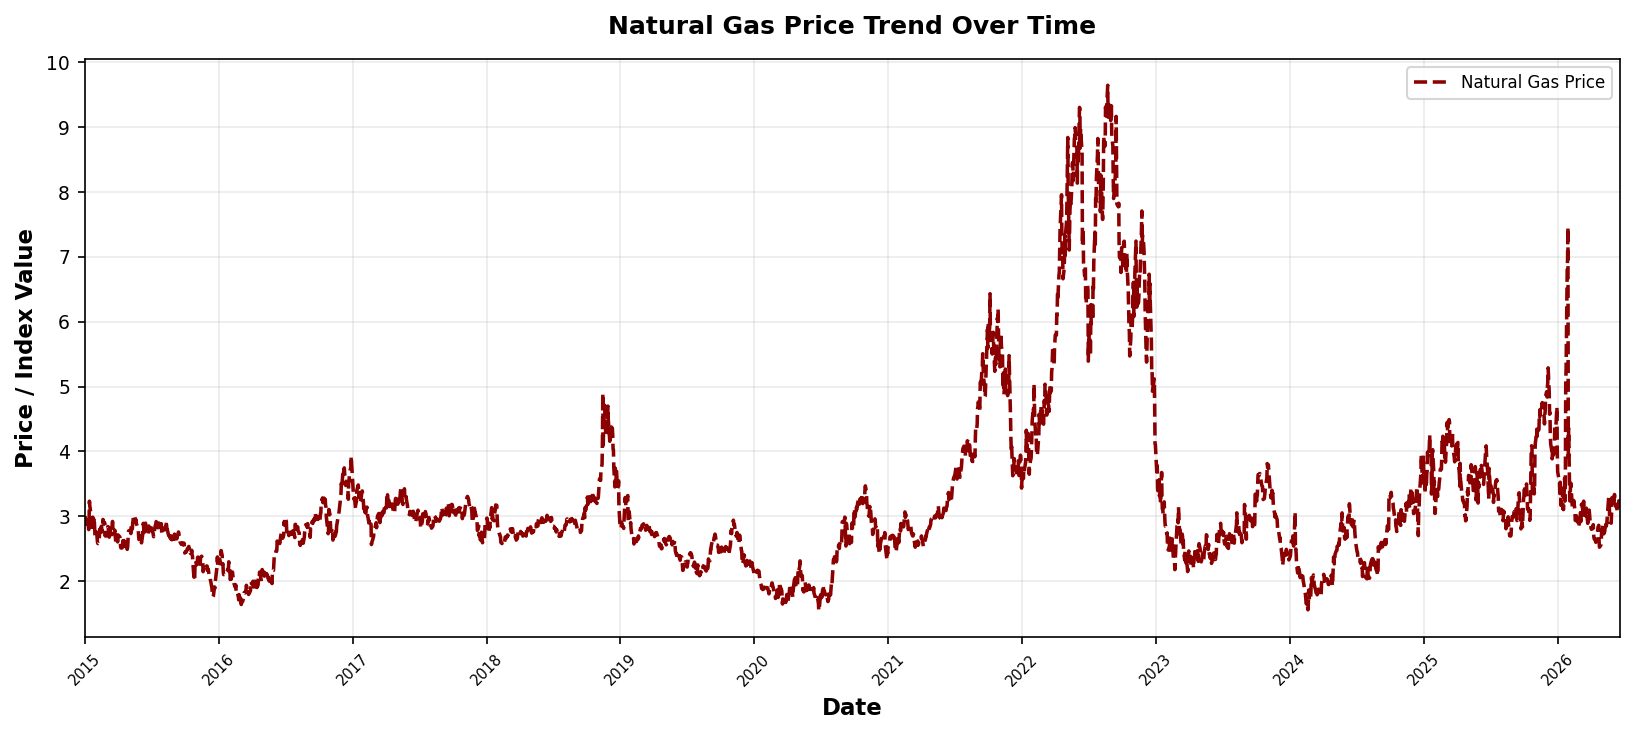

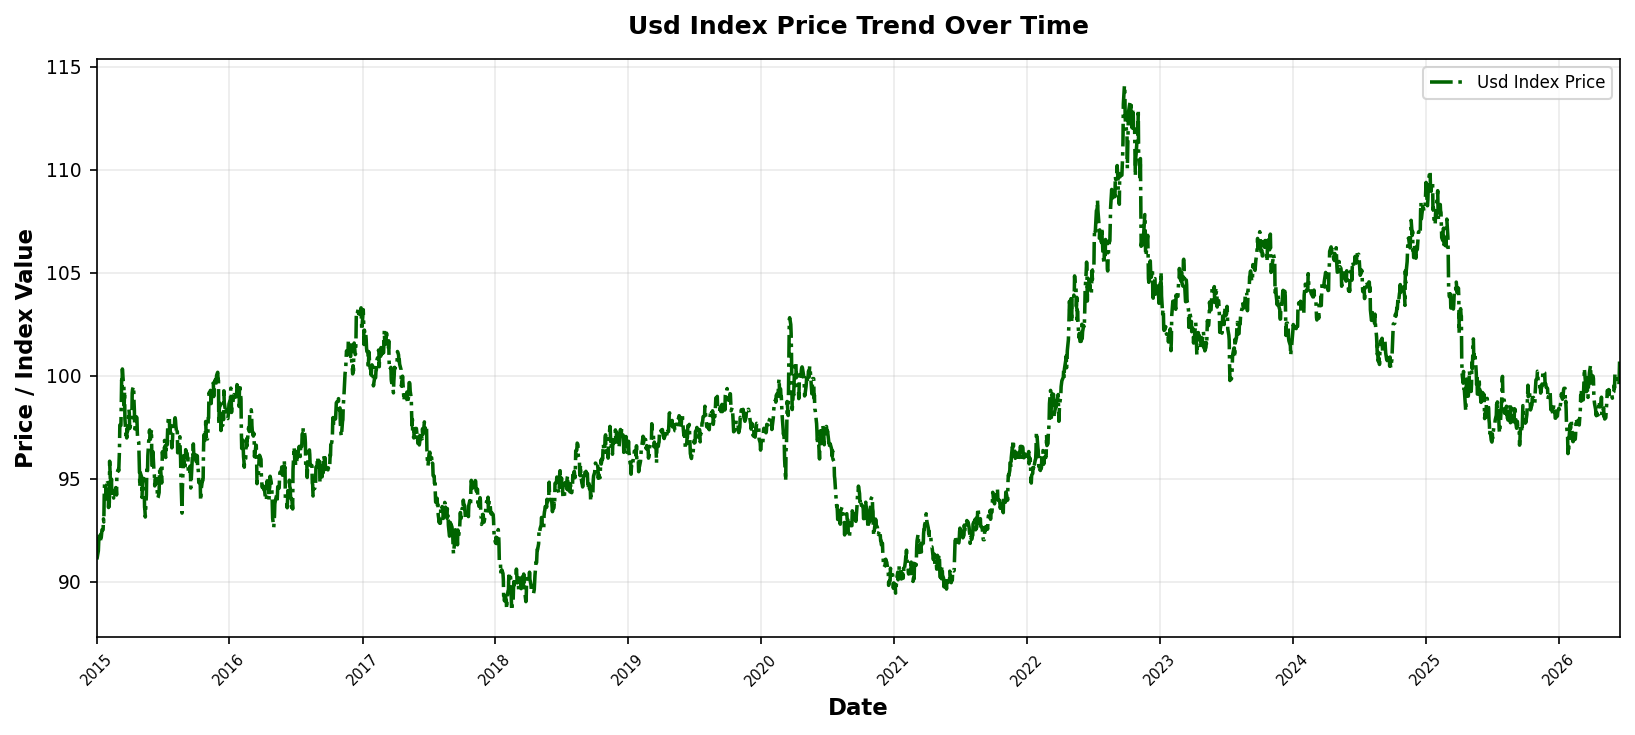

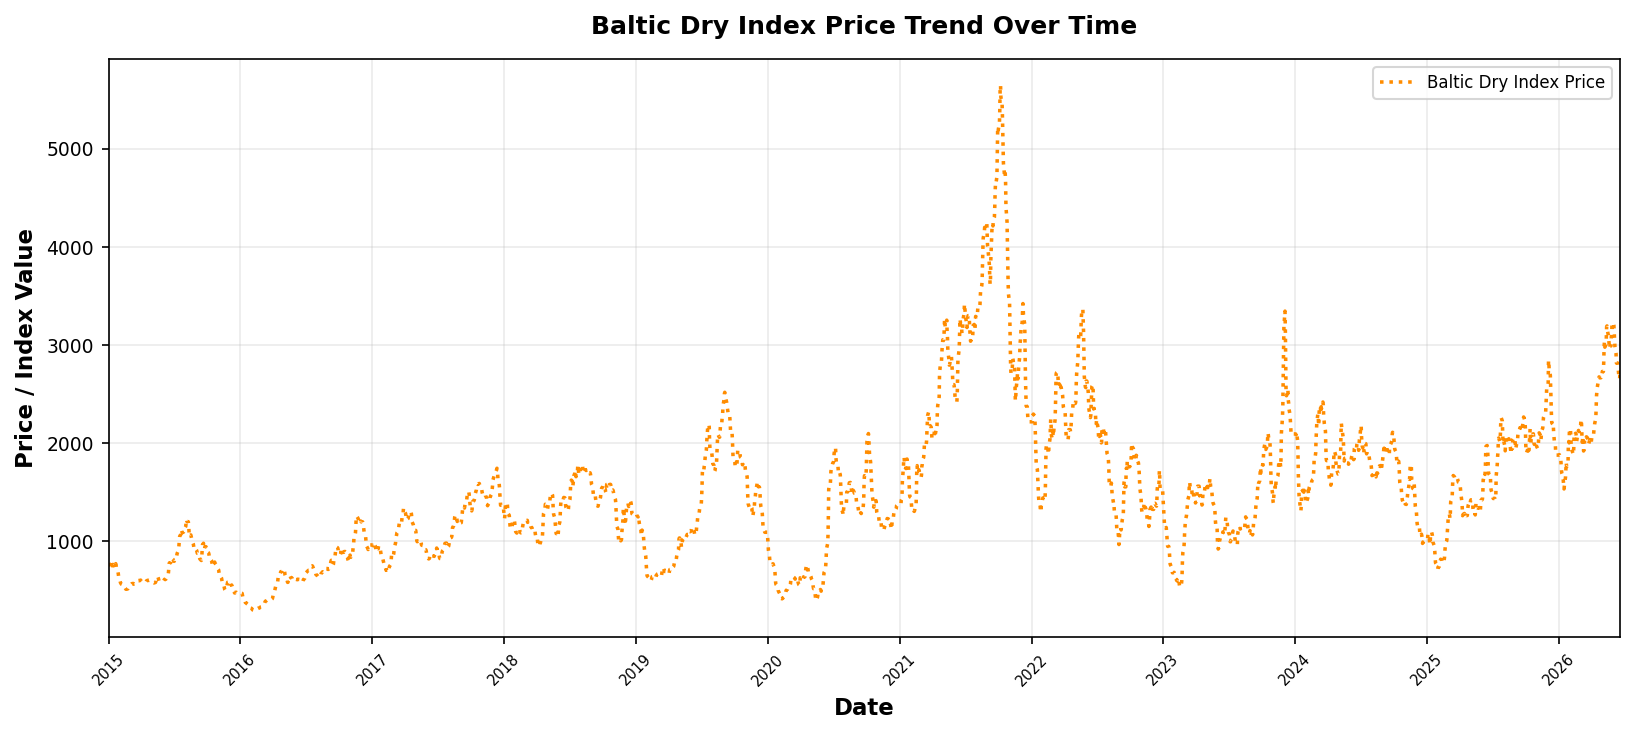

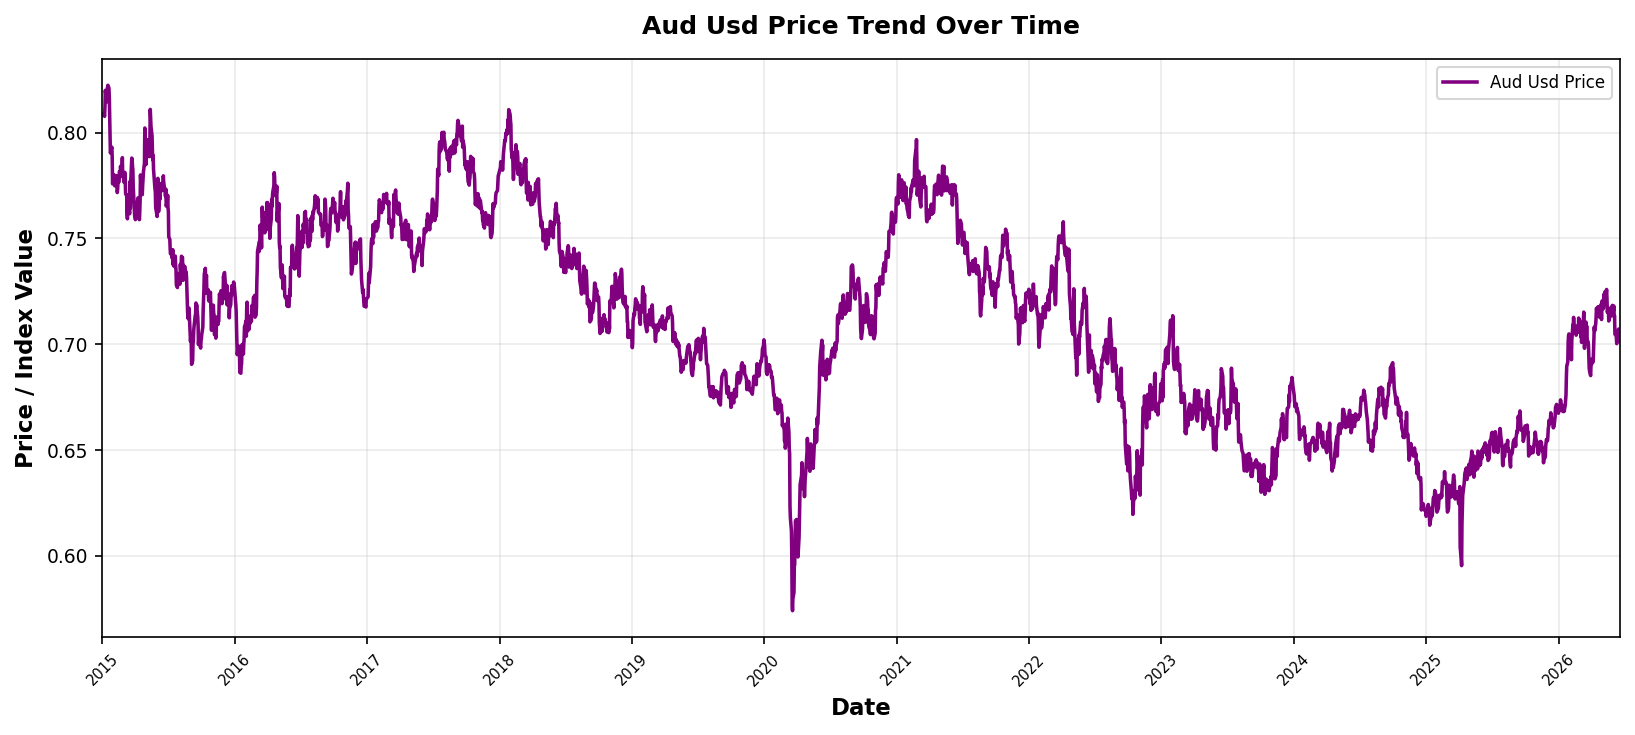

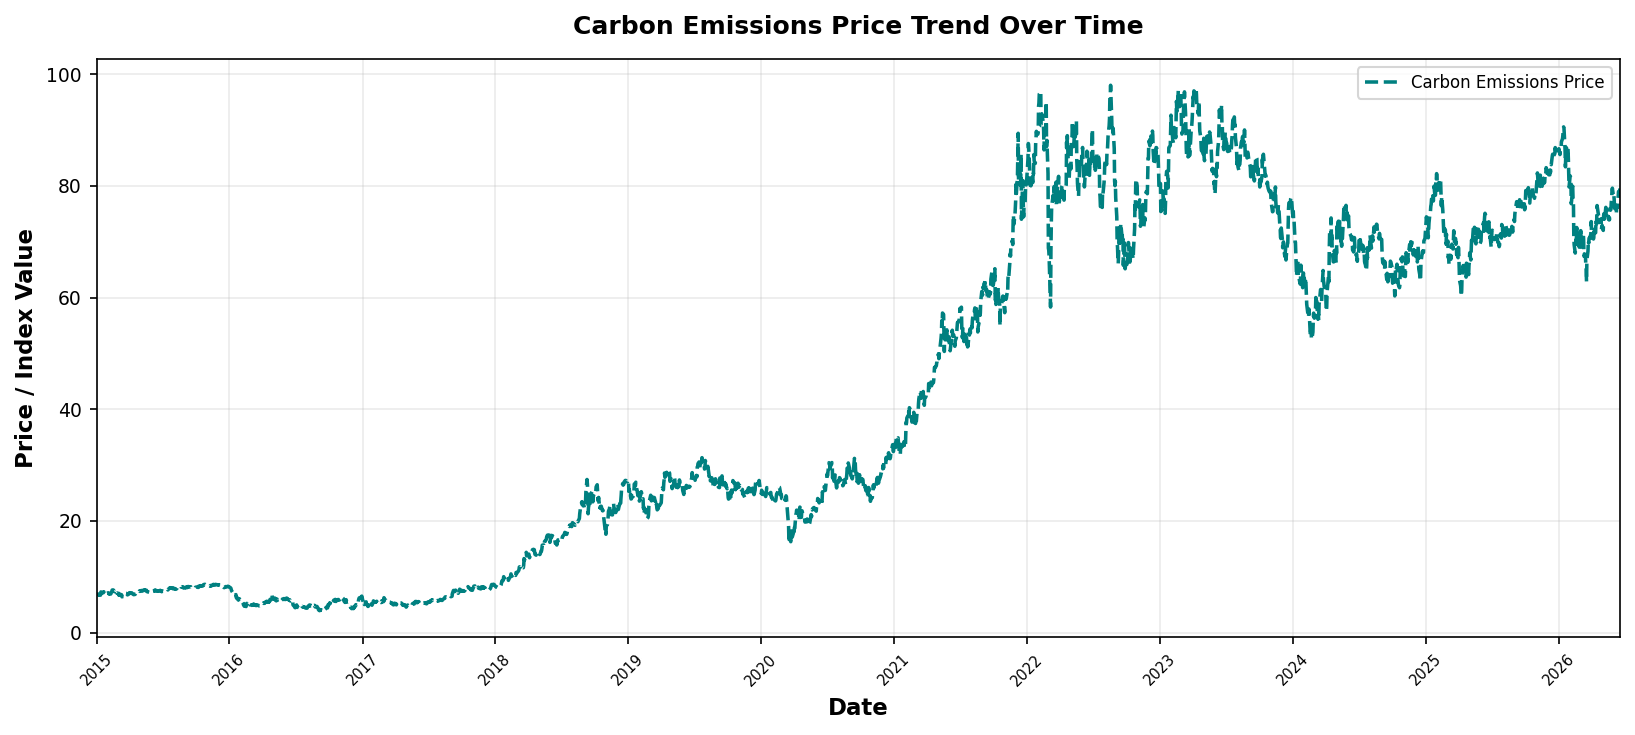

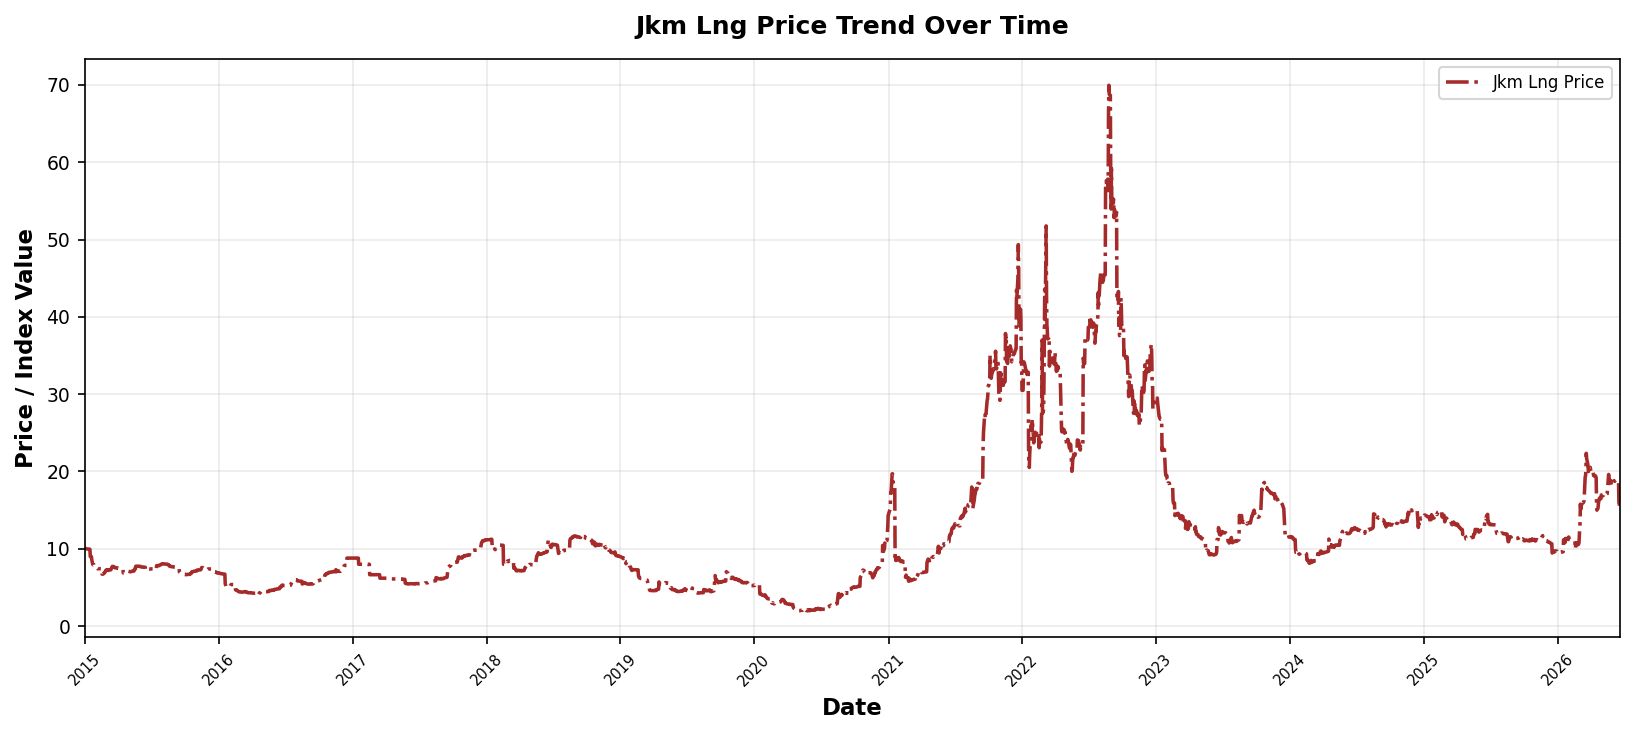

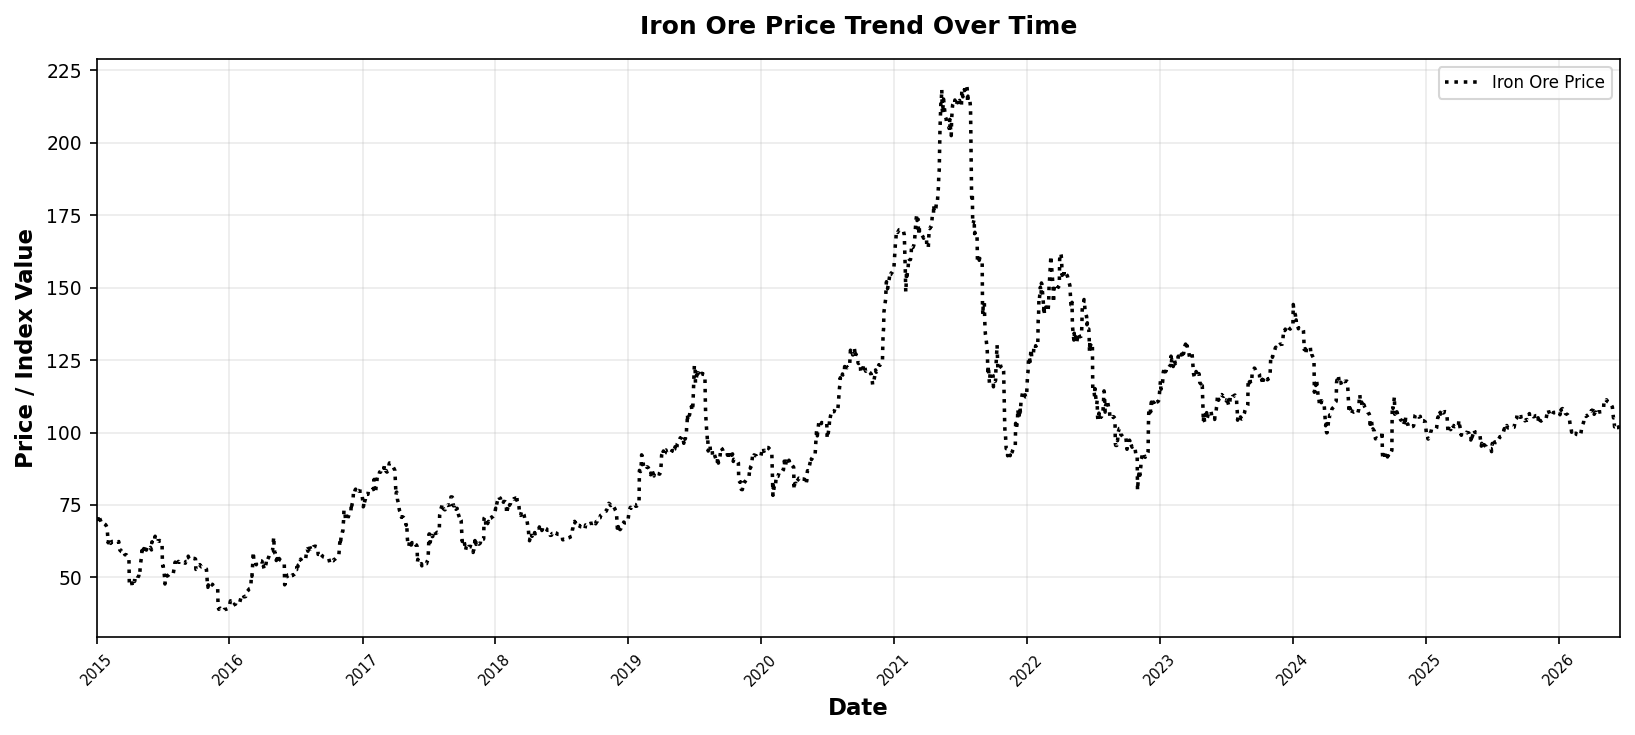

In [185]:
# 6.3 Analyze Key Market Variable Trends

# Here, I am selecting only the main price columns of the market variables.
# The target column is excluded because Newcastle coal price was already analysed separately.
market_price_cols = [
    col for col in eda_df.columns
    if col.endswith("_price") and col != target_col
]

# Check which market variables are going into this trend analysis.
print("Market price variables selected for EDA trend analysis:")
for col in market_price_cols:
    print("-", col)

print("\nTotal market variables selected:", len(market_price_cols))

# I am using different colours and line styles so each chart looks visually different.
# This also helps when screenshots are added to the final report.
plot_colors = ["darkblue", "darkred", "darkgreen", "darkorange", "purple", "teal", "brown", "black"]
line_styles = ["-", "--", "-.", ":"]

# Prepare yearly labels once so every chart follows the same date format.
start_year = eda_df["Date"].dt.year.min()
end_year = eda_df["Date"].dt.year.max()

year_ticks = pd.date_range(
    start=f"{start_year}-01-01",
    end=f"{end_year}-12-31",
    freq="YS"
)

# Plot each variable separately because these market indicators have different scales.
# For example, AUD/USD and Baltic Dry Index cannot be compared clearly on the same y-axis.
for i, col in enumerate(market_price_cols):

    readable_name = col.replace("_", " ").title()
    line_color = plot_colors[i % len(plot_colors)]
    line_style = line_styles[i % len(line_styles)]

    plt.figure(figsize=(11, 5), dpi=150)

    plt.plot(
        eda_df["Date"],
        eda_df[col],
        color=line_color,
        linewidth=1.7,
        linestyle=line_style,
        label=readable_name
    )

    plt.title(f"{readable_name} Trend Over Time", fontsize=12, fontweight="bold", pad=12)
    plt.xlabel("Date", fontsize=11, fontweight="bold")
    plt.ylabel("Price / Index Value", fontsize=11, fontweight="bold")

    # Show every year clearly, including the first year in the dataset.
    plt.xticks(
        ticks=year_ticks,
        labels=[str(year.year) for year in year_ticks],
        rotation=45,
        fontsize=7
    )

    plt.xlim(pd.Timestamp(f"{start_year}-01-01"), eda_df["Date"].max())
    plt.yticks(fontsize=9)

    plt.grid(True, alpha=0.25)
    plt.legend(fontsize=8, frameon=True)
    plt.tight_layout()
    plt.show()

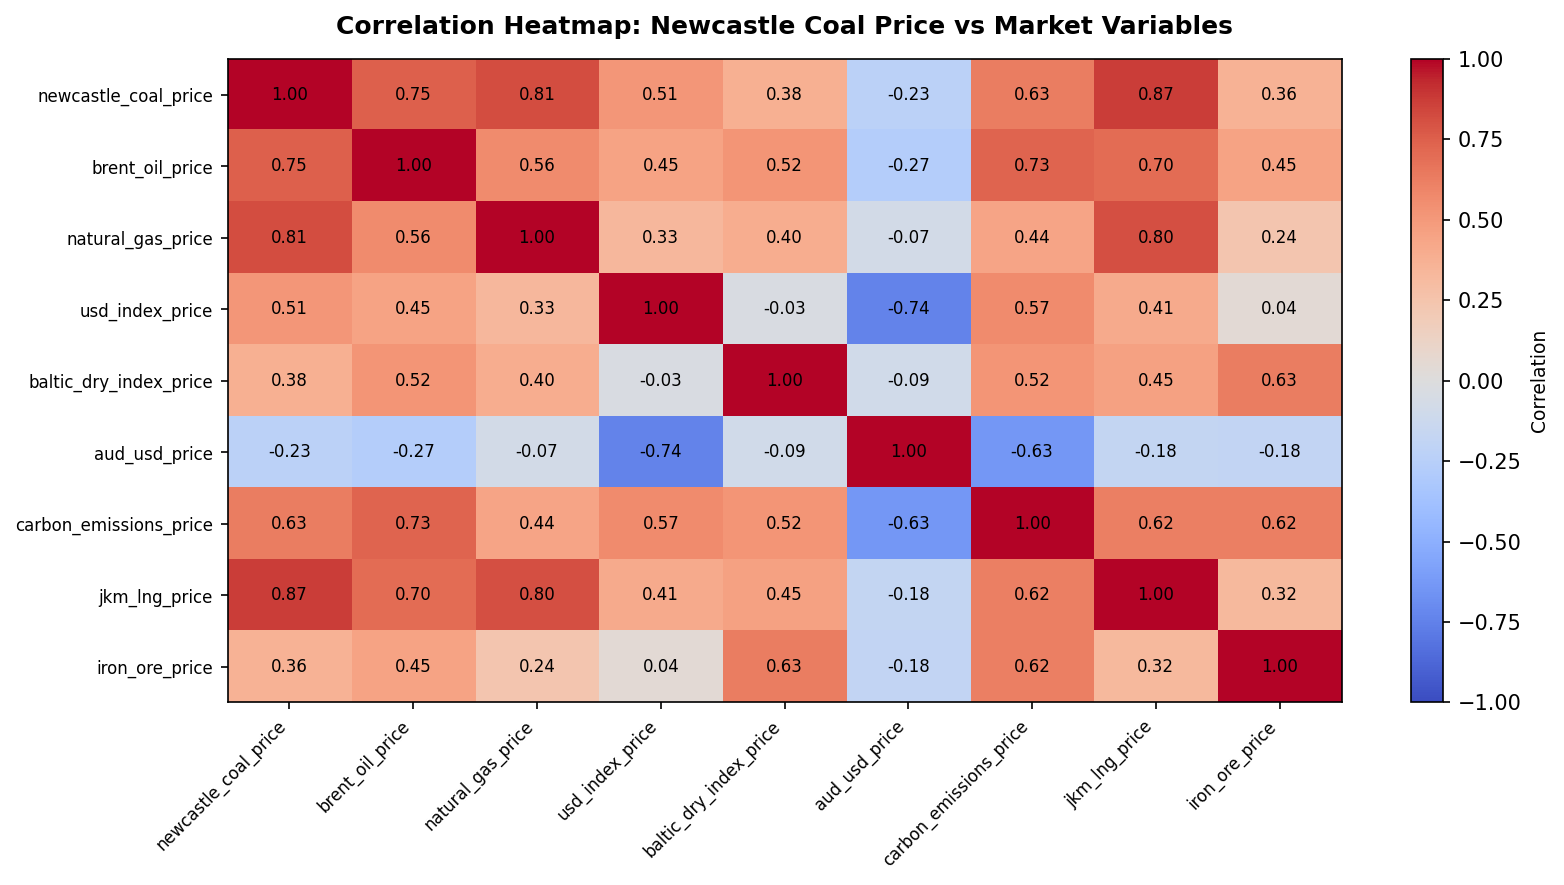

,correlation_with_newcastle_coal_price
jkm_lng_price,0.870710
natural_gas_price,0.813054
brent_oil_price,0.747944
carbon_emissions_price,0.631688
usd_index_price,0.513494
baltic_dry_index_price,0.377224
iron_ore_price,0.360258
aud_usd_price,-0.232226


In [186]:
# 6.4 Correlation Analysis

# Use the target price and selected market price variables for correlation analysis.
# This helps us see which variables have stronger or weaker relationships with coal prices.
corr_cols = [target_col] + market_price_cols
corr_data = eda_df[corr_cols].copy()

# Calculate the correlation matrix.
corr_matrix = corr_data.corr()

# Create a clean heatmap without internal grid lines.
fig, ax = plt.subplots(figsize=(11, 6), dpi=150)

heatmap = ax.imshow(
    corr_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="auto"
)

# Add correlation values inside each cell.
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        value = corr_matrix.iloc[i, j]
        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color="black"
        )

# Add variable names to both axes.
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.index)))

ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(corr_matrix.index, fontsize=8)

# Remove any grid lines completely.
ax.grid(False)

# Add title and color scale.
ax.set_title(
    "Correlation Heatmap: Newcastle Coal Price vs Market Variables",
    fontsize=12,
    fontweight="bold",
    pad=12
)

colorbar = plt.colorbar(heatmap, ax=ax)
colorbar.set_label("Correlation", fontsize=9)

plt.tight_layout()
plt.show()

# Rank variables by correlation with Newcastle coal price.
coal_corr_rank = (
    corr_matrix[target_col]
    .drop(target_col)
    .sort_values(ascending=False)
)

display(coal_corr_rank.to_frame(name="correlation_with_newcastle_coal_price"))

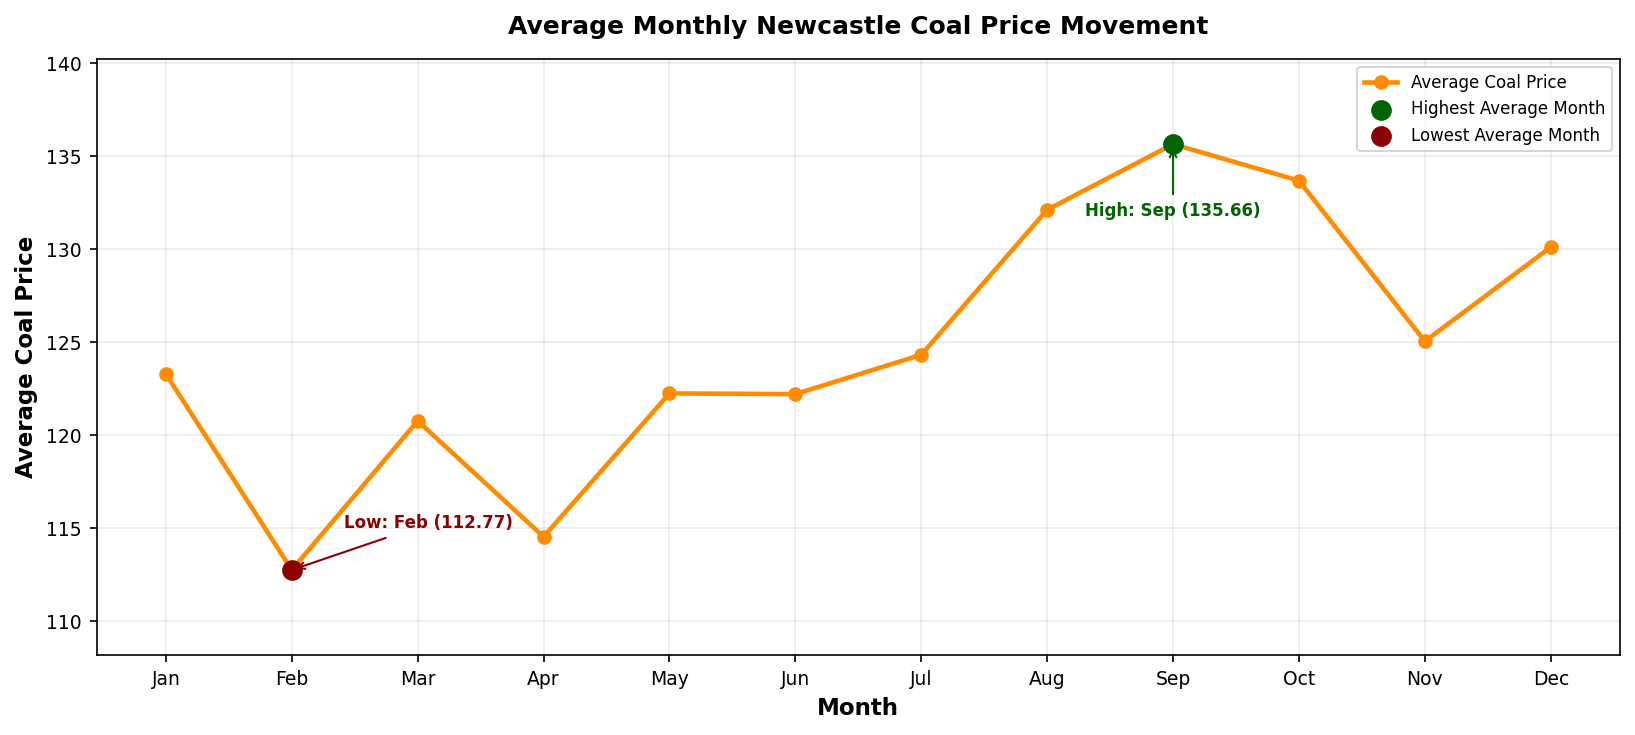

In [187]:
# 6.5 Monthly Coal Price Movement

# Calculate monthly average coal price to check for seasonal movement.
monthly_coal_price = (
    eda_df
    .assign(
        month=eda_df["Date"].dt.month,
        month_name=eda_df["Date"].dt.strftime("%b")
    )
    .groupby(["month", "month_name"], as_index=False)[target_col]
    .mean()
    .sort_values("month")
    .reset_index(drop=True)
)

# Identify the highest and lowest average price months.
highest_month = monthly_coal_price.loc[monthly_coal_price[target_col].idxmax()]
lowest_month = monthly_coal_price.loc[monthly_coal_price[target_col].idxmin()]

high_idx = monthly_coal_price[target_col].idxmax()
low_idx = monthly_coal_price[target_col].idxmin()

x_pos = range(len(monthly_coal_price))

plt.figure(figsize=(11, 5), dpi=150)

plt.plot(
    x_pos,
    monthly_coal_price[target_col],
    color="darkorange",
    linewidth=2.2,
    marker="o",
    label="Average Coal Price"
)

# Mark highest average month.
plt.scatter(
    high_idx,
    highest_month[target_col],
    color="darkgreen",
    s=80,
    zorder=5,
    label="Highest Average Month"
)

plt.annotate(
    f"High: {highest_month['month_name']} ({highest_month[target_col]:.2f})",
    xy=(high_idx, highest_month[target_col]),
    xytext=(0, -28),
    textcoords="offset points",
    ha="center",
    va="top",
    fontsize=8,
    fontweight="bold",
    color="darkgreen",
    arrowprops=dict(arrowstyle="->", color="darkgreen", lw=1)
)

# Mark lowest average month.
plt.scatter(
    low_idx,
    lowest_month[target_col],
    color="darkred",
    s=80,
    zorder=5,
    label="Lowest Average Month"
)

plt.annotate(
    f"Low: {lowest_month['month_name']} ({lowest_month[target_col]:.2f})",
    xy=(low_idx, lowest_month[target_col]),
    xytext=(25, 18),
    textcoords="offset points",
    ha="left",
    va="bottom",
    fontsize=8,
    fontweight="bold",
    color="darkred",
    arrowprops=dict(arrowstyle="->", color="darkred", lw=1)
)

plt.title(
    "Average Monthly Newcastle Coal Price Movement",
    fontsize=12,
    fontweight="bold",
    pad=12
)

plt.xlabel("Month", fontsize=11, fontweight="bold")
plt.ylabel("Average Coal Price", fontsize=11, fontweight="bold")

plt.xticks(
    ticks=x_pos,
    labels=monthly_coal_price["month_name"],
    fontsize=9
)

plt.yticks(fontsize=9)

# Add padding so labels stay inside the chart.
y_min = monthly_coal_price[target_col].min()
y_max = monthly_coal_price[target_col].max()
y_padding = (y_max - y_min) * 0.20

plt.ylim(y_min - y_padding, y_max + y_padding)

plt.grid(True, alpha=0.25)
plt.legend(fontsize=8, frameon=True)
plt.tight_layout()
plt.show()

In [188]:
#6.6  Monthly summary table with average, minimum, maximum, and volatility.

monthly_summary_table = (
    eda_df
    .assign(
        month=eda_df["Date"].dt.month,
        month_name=eda_df["Date"].dt.strftime("%b")
    )
    .groupby(["month", "month_name"], as_index=False)
    .agg(
        average_coal_price=(target_col, "mean"),
        min_coal_price=(target_col, "min"),
        max_coal_price=(target_col, "max"),
        monthly_volatility=(target_col, "std")
    )
    .sort_values("month")
    .reset_index(drop=True)
)

monthly_summary_table[
    ["average_coal_price", "min_coal_price", "max_coal_price", "monthly_volatility"]
] = monthly_summary_table[
    ["average_coal_price", "min_coal_price", "max_coal_price", "monthly_volatility"]
].round(2)

display(monthly_summary_table)

,month,month_name,average_coal_price,min_coal_price,max_coal_price,monthly_volatility
0,1,Jan,123.30,48.80,397.50,82.67
1,2,Feb,112.77,49.95,274.50,56.04
2,3,Mar,120.78,50.50,440.00,79.27
3,4,Apr,114.55,49.60,331.10,68.37
4,5,May,122.26,50.20,427.00,88.61
5,6,Jun,122.22,52.15,415.25,90.45
6,7,Jul,124.33,51.60,430.00,93.37
7,8,Aug,132.13,49.50,425.00,96.11
8,9,Sep,135.66,48.50,457.80,106.02
9,10,Oct,133.70,52.80,404.00,92.87


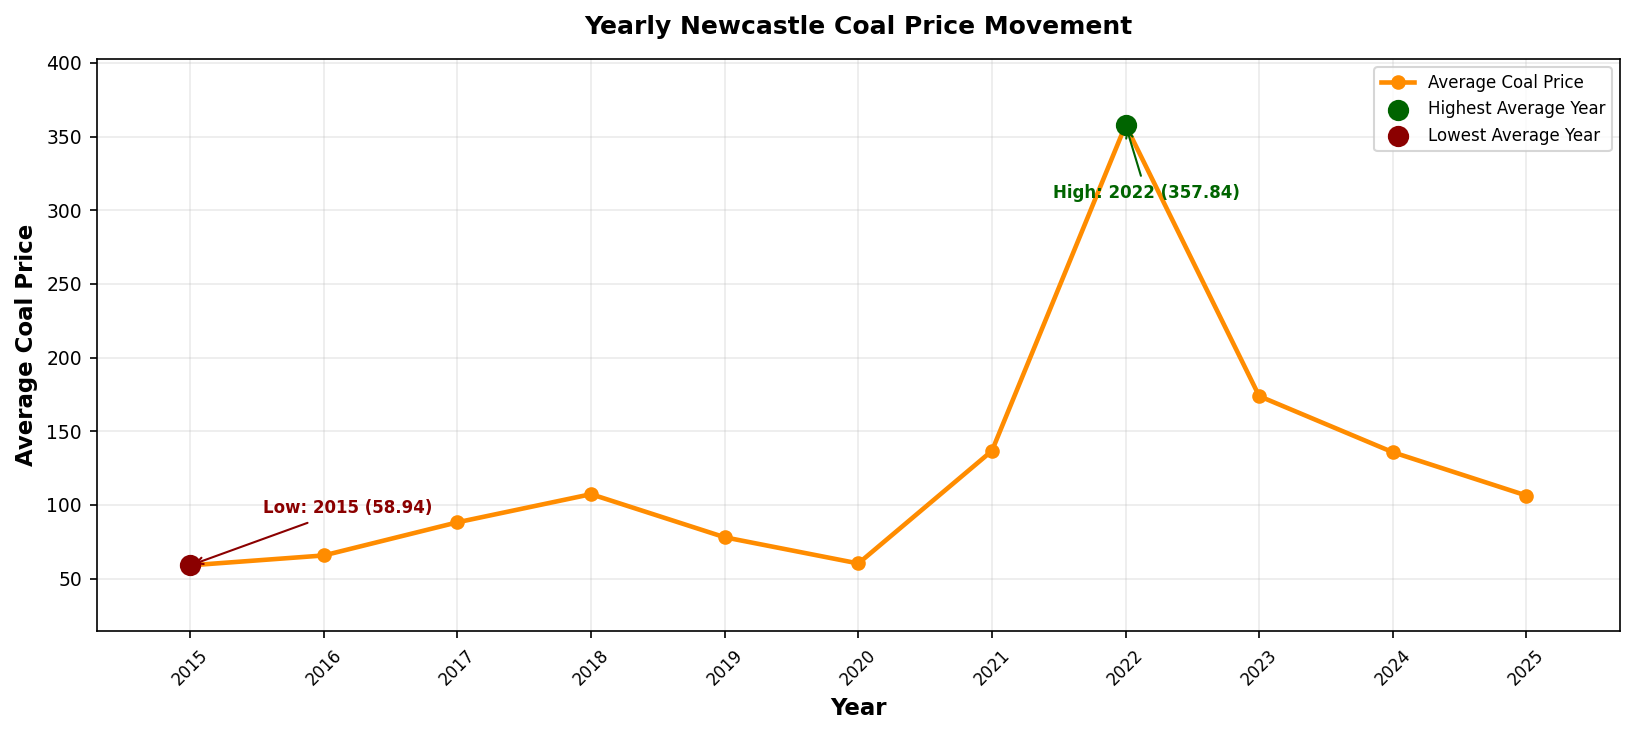

In [189]:
# 6.7 Yearly Coal Price Movement

# Here i'm  using historical data only up to Dec 2025.
# Jan-Jun 2026 is the forecast period so it is kept out of this EDA view.
historical_eda_df = eda_df[eda_df["Date"] <= "2025-12-31"]

# Calculate average Newcastle coal price for each year.
yearly_coal_price = (
    historical_eda_df
    .assign(year=historical_eda_df["Date"].dt.year)
    .groupby("year", as_index=False)[target_col]
    .mean()
)

# Find highest and lowest average coal price years.
highest_year = yearly_coal_price.loc[yearly_coal_price[target_col].idxmax()]
lowest_year = yearly_coal_price.loc[yearly_coal_price[target_col].idxmin()]

high_idx = yearly_coal_price[target_col].idxmax()
low_idx = yearly_coal_price[target_col].idxmin()

# Numeric x positions help us control label placement better.
x_pos = range(len(yearly_coal_price))

plt.figure(figsize=(11, 5), dpi=150)

plt.plot(
    x_pos,
    yearly_coal_price[target_col],
    color="darkorange",
    linewidth=2.2,
    marker="o",
    label="Average Coal Price"
)

# Mark highest average year.
plt.scatter(
    high_idx,
    highest_year[target_col],
    color="darkgreen",
    s=85,
    zorder=5,
    label="Highest Average Year"
)

plt.annotate(
    f"High: {int(highest_year['year'])} ({highest_year[target_col]:.2f})",
    xy=(high_idx, highest_year[target_col]),
    xytext=(-35, -35),
    textcoords="offset points",
    fontsize=8,
    fontweight="bold",
    color="darkgreen",
    arrowprops=dict(arrowstyle="->", color="darkgreen", lw=1)
)

# Mark lowest average year.
plt.scatter(
    low_idx,
    lowest_year[target_col],
    color="darkred",
    s=85,
    zorder=5,
    label="Lowest Average Year"
)

plt.annotate(
    f"Low: {int(lowest_year['year'])} ({lowest_year[target_col]:.2f})",
    xy=(low_idx, lowest_year[target_col]),
    xytext=(35, 25),
    textcoords="offset points",
    fontsize=8,
    fontweight="bold",
    color="darkred",
    arrowprops=dict(arrowstyle="->", color="darkred", lw=1)
)

plt.title(
    "Yearly Newcastle Coal Price Movement",
    fontsize=12,
    fontweight="bold",
    pad=12
)

plt.xlabel("Year", fontsize=11, fontweight="bold")
plt.ylabel("Average Coal Price", fontsize=11, fontweight="bold")

plt.xticks(
    ticks=x_pos,
    labels=yearly_coal_price["year"],
    rotation=45,
    fontsize=8
)

plt.yticks(fontsize=9)

# Add side and vertical padding so labels do not get cut.
plt.xlim(-0.7, len(yearly_coal_price) - 0.3)

y_min = yearly_coal_price[target_col].min()
y_max = yearly_coal_price[target_col].max()
y_padding = (y_max - y_min) * 0.15

plt.ylim(y_min - y_padding, y_max + y_padding)

plt.grid(True, alpha=0.25)
plt.legend(fontsize=8, frameon=True)
plt.tight_layout()
plt.show()

In [190]:
# 6.8 Yearly summary table for exact values.

yearly_summary_table = (
    historical_eda_df
    .assign(year=historical_eda_df["Date"].dt.year)
    .groupby("year", as_index=False)
    .agg(
        average_coal_price=(target_col, "mean"),
        min_coal_price=(target_col, "min"),
        max_coal_price=(target_col, "max"),
        yearly_volatility=(target_col, "std")
    )
)

yearly_summary_table[
    ["average_coal_price", "min_coal_price", "max_coal_price", "yearly_volatility"]
] = yearly_summary_table[
    ["average_coal_price", "min_coal_price", "max_coal_price", "yearly_volatility"]
].round(2)

display(yearly_summary_table)

,year,average_coal_price,min_coal_price,max_coal_price,yearly_volatility
0,2015,58.94,50.60,71.10,4.94
1,2016,65.65,48.80,114.75,18.36
2,2017,88.16,73.25,101.20,8.64
3,2018,107.25,92.00,119.90,7.58
4,2019,77.99,64.80,101.10,12.40
5,2020,60.22,48.50,85.35,8.79
6,2021,136.68,79.45,269.50,45.45
7,2022,357.84,157.50,457.80,71.39
8,2023,173.80,119.00,397.50,63.72
9,2024,135.72,116.00,150.00,7.97


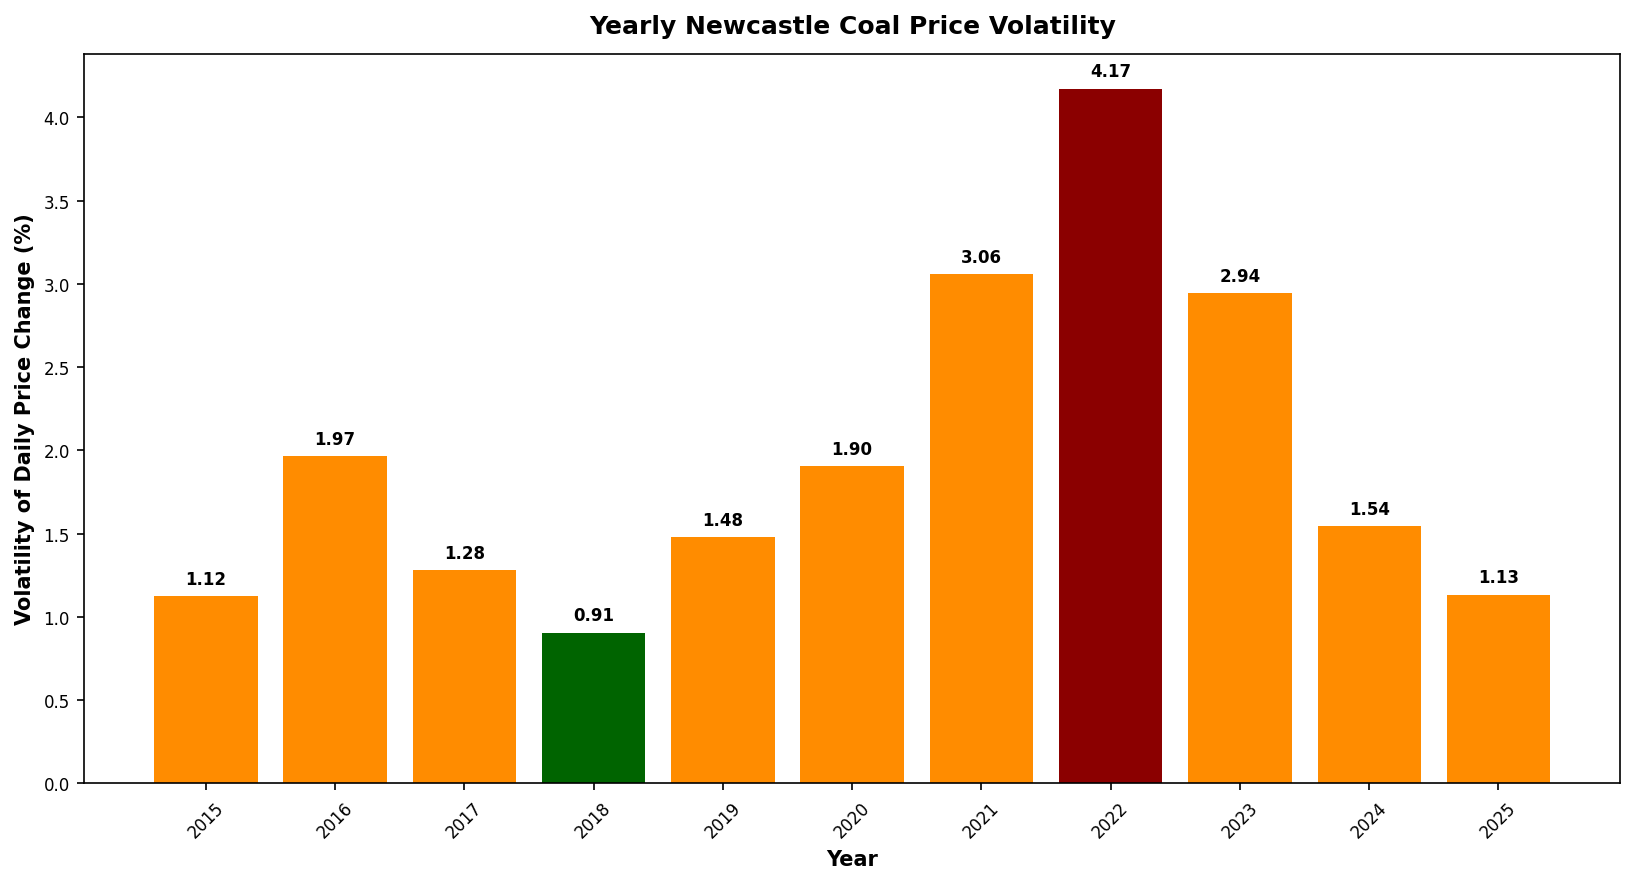

In [191]:
# 6.9 Coal Price Volatility

# Calculate daily percentage change first.
# This helps us measure how unstable coal prices were within each year.
volatility_by_year = (
    historical_eda_df
    .assign(
        year=historical_eda_df["Date"].dt.year,
        daily_return_pct=historical_eda_df[target_col].pct_change() * 100
    )
    .groupby("year", as_index=False)
    .agg(yearly_volatility=("daily_return_pct", "std"))
)

# Find the most and least volatile years.
highest_vol_year = volatility_by_year.loc[volatility_by_year["yearly_volatility"].idxmax()]
lowest_vol_year = volatility_by_year.loc[volatility_by_year["yearly_volatility"].idxmin()]

# Use simple colours to highlight the key years.
bar_colors = [
    "darkred" if year == highest_vol_year["year"]
    else "darkgreen" if year == lowest_vol_year["year"]
    else "darkorange"
    for year in volatility_by_year["year"]
]

plt.figure(figsize=(11, 6), dpi=150)

bars = plt.bar(
    volatility_by_year["year"],
    volatility_by_year["yearly_volatility"],
    color=bar_colors
)

# Add exact volatility value on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.05,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold"
    )

plt.title(
    "Yearly Newcastle Coal Price Volatility",
    fontsize=12,
    fontweight="bold",
    pad=10
)

plt.xlabel("Year", fontsize=10, fontweight="bold")
plt.ylabel("Volatility of Daily Price Change (%)", fontsize=10, fontweight="bold")

plt.xticks(volatility_by_year["year"], rotation=45, fontsize=8)
plt.yticks(fontsize=8)

# Remove grid lines to keep the chart clean.
plt.grid(False)

plt.tight_layout()
plt.show()

## **7. Data Processing & Feature Engineering**

In this section, the cleaned master dataset is converted into a model-ready dataset for forecasting coal prices.

The main objective is to prepare historical data up to December 2025 and create meaningful time-series features such as date features, lag features, rolling features, and market driver features. These features will later be used for SARIMAX, XGBoost, and LSTM model development.

This section does not repeat earlier raw data cleaning, date conversion, numeric conversion, or dataset merging because those steps were already completed in the previous sections.

In [192]:
# 7.1 Creating a separate modeling dataset from the cleaned master dataset
model_df = master_df.copy()

# Ensure data is sorted by date before feature engineering
model_df = model_df.sort_values("Date").reset_index(drop=True)

print("Modeling dataset created successfully.")
print("Shape:", model_df.shape)
print("Date range:", model_df["Date"].min(), "to", model_df["Date"].max())

model_df.head()

Modeling dataset created successfully.
Shape: (2955, 46)
Date range: 2015-01-02 00:00:00 to 2026-06-19 00:00:00


,Date,newcastle_coal_price,newcastle_coal_open,newcastle_coal_high,newcastle_coal_low,newcastle_coal_change_pct,brent_oil_price,brent_oil_open,brent_oil_high,brent_oil_low,...,jkm_lng_price,jkm_lng_open,jkm_lng_high,jkm_lng_low,jkm_lng_change_pct,iron_ore_price,iron_ore_open,iron_ore_high,iron_ore_low,iron_ore_change_pct
0,2015-01-02,61.30,61.30,61.30,61.30,-1.61,56.42,58.02,58.54,55.48,...,10.055,10.055,10.055,10.055,0.0,70.06,70.06,70.06,70.06,1.65
1,2015-01-05,61.25,61.25,61.25,61.25,-0.08,53.11,56.25,56.30,52.66,...,10.005,10.005,10.005,10.005,-0.5,69.98,69.98,69.98,69.98,-0.11
2,2015-01-06,61.45,61.45,61.45,61.45,0.33,51.10,53.20,53.60,50.52,...,9.985,9.985,9.985,9.985,-0.2,71.57,71.57,71.57,71.57,2.27
3,2015-01-07,60.60,60.60,60.60,60.60,-1.38,51.15,51.15,51.84,49.66,...,9.985,9.985,9.985,9.985,0.0,71.24,71.24,71.24,71.24,-0.46
4,2015-01-08,60.60,60.60,60.60,60.60,0.00,50.96,51.06,51.91,49.81,...,9.975,9.975,9.975,9.975,-0.1,70.95,70.95,70.95,70.95,-0.41


In [193]:
# 7.2 Quick check before selecting columns and creating new features

print("Shape:", model_df.shape)
print("Duplicate dates:", model_df["Date"].duplicated().sum())
print("Missing values:", model_df.isna().sum().sum())

missing_summary = model_df.isna().sum()
missing_summary = missing_summary[missing_summary > 0]

if len(missing_summary) > 0:
    display(missing_summary.sort_values(ascending=False))
else:
    print("No missing values found.")

Shape: (2955, 46)
Duplicate dates: 0
Missing values: 0
No missing values found.


In [194]:
# 7.3 Checking whether open, high, low, and change % add different information from closing price
price_cols = [col for col in model_df.columns if col.endswith("_price")]
check_types = ["open", "high", "low", "change_pct"]

column_check = []

for price_col in price_cols:
    base = price_col.replace("_price", "")

    for item in check_types:
        check_col = f"{base}_{item}"

        if check_col in model_df.columns:
            column_check.append([
                price_col,
                check_col,
                round(model_df[price_col].corr(model_df[check_col]), 4)
            ])

column_check = pd.DataFrame(
    column_check,
    columns=["price_column", "checked_column", "correlation"]
)

column_check

,price_column,checked_column,correlation
0,newcastle_coal_price,newcastle_coal_open,0.9996
1,newcastle_coal_price,newcastle_coal_high,0.9997
2,newcastle_coal_price,newcastle_coal_low,0.9997
3,newcastle_coal_price,newcastle_coal_change_pct,0.0321
4,brent_oil_price,brent_oil_open,0.9963
5,brent_oil_price,brent_oil_high,0.9977
6,brent_oil_price,brent_oil_low,0.9984
7,brent_oil_price,brent_oil_change_pct,0.0416
8,natural_gas_price,natural_gas_open,0.9952
9,natural_gas_price,natural_gas_high,0.9979


In [195]:
# 7.4 Keep the final base columns for modelling
# Extra OHLC and change % columns were reviewed above, so only closing prices are retained

price_cols = [col for col in model_df.columns if col.endswith("_price")]

model_df = model_df[["Date"] + price_cols].copy()

print("Model base shape:", model_df.shape)
model_df.head()

Model base shape: (2955, 10)


,Date,newcastle_coal_price,brent_oil_price,natural_gas_price,usd_index_price,baltic_dry_index_price,aud_usd_price,carbon_emissions_price,jkm_lng_price,iron_ore_price
0,2015-01-02,61.30,56.42,3.003,91.08,771.0,0.8087,7.01,10.055,70.06
1,2015-01-05,61.25,53.11,2.882,91.38,761.0,0.8082,6.90,10.005,69.98
2,2015-01-06,61.45,51.10,2.938,91.50,758.0,0.8084,6.77,9.985,71.57
3,2015-01-07,60.60,51.15,2.871,91.89,744.0,0.8077,6.78,9.985,71.24
4,2015-01-08,60.60,50.96,2.927,92.37,724.0,0.8122,6.81,9.975,70.95


In [196]:
# 7.5 Converting AUD/USD from decimal rate to US cents for easier reading
# Example- 0.8087 becomes 80.87 cents per 1 AUD

if "aud_usd_price" in model_df.columns and model_df["aud_usd_price"].max() < 2:
    model_df["aud_usd_price"] = model_df["aud_usd_price"] * 100

print("AUD/USD converted to cents.")
model_df[["Date", "aud_usd_price"]].head()

AUD/USD converted to cents.


,Date,aud_usd_price
0,2015-01-02,80.87
1,2015-01-05,80.82
2,2015-01-06,80.84
3,2015-01-07,80.77
4,2015-01-08,81.22


In [197]:
# 7.6 Keep historical data separate from the Jan-Jun 2026 forecast period
historical_end = "2025-12-31"
forecast_start = "2026-01-01"
forecast_end = "2026-06-30"

historical_df = model_df[model_df["Date"] <= historical_end].copy()

forecast_df = model_df[
    (model_df["Date"] >= forecast_start) &
    (model_df["Date"] <= forecast_end)
].copy()

print("Historical data:", historical_df.shape)
print("Forecast data:", forecast_df.shape)

Historical data: (2835, 10)
Forecast data: (120, 10)


In [198]:
# 7.8 Check the actual date range available in the forecast period
print("Forecast start:", forecast_df["Date"].min())
print("Forecast end:", forecast_df["Date"].max())
print("Forecast rows:", forecast_df.shape[0])

Forecast start: 2026-01-02 00:00:00
Forecast end: 2026-06-19 00:00:00
Forecast rows: 120


**Note:** The forecast comparison period contains available market records from January to June 2026. Commodity and financial market datasets usually do not include weekends, exchange holidays, or non-trading dates. In this dataset, the available forecast-period records start from 02 Jan 2026 and end on 19 Jun 2026. Therefore, the 120 rows represent available trading days, not full calendar days.

In [199]:
# 7.9  Here I'm going to add simple date features so the model can learn yearly and seasonal patterns
model_df["year"] = model_df["Date"].dt.year
model_df["month"] = model_df["Date"].dt.month
model_df["quarter"] = model_df["Date"].dt.quarter

print("Date features added.")
model_df[["Date", "year", "month", "quarter"]].head(5)

Date features added.


,Date,year,month,quarter
0,2015-01-02,2015,1,1
1,2015-01-05,2015,1,1
2,2015-01-06,2015,1,1
3,2015-01-07,2015,1,1
4,2015-01-08,2015,1,1


In [200]:
# 7.10 Create coal lag features to capture short-term and monthly coal price movement
target_col = "newcastle_coal_price"

model_df["coal_lag_1"] = model_df[target_col].shift(1)
model_df["coal_lag_7"] = model_df[target_col].shift(7)
model_df["coal_lag_30"] = model_df[target_col].shift(30)

lag_cols = ["coal_lag_1", "coal_lag_7", "coal_lag_30"]

print("Coal lag features created.")
model_df[["Date", target_col] + lag_cols].head(10)

Coal lag features created.


,Date,newcastle_coal_price,coal_lag_1,coal_lag_7,coal_lag_30
0,2015-01-02,61.30,NaN,NaN,NaN
1,2015-01-05,61.25,61.30,NaN,NaN
2,2015-01-06,61.45,61.25,NaN,NaN
3,2015-01-07,60.60,61.45,NaN,NaN
4,2015-01-08,60.60,60.60,NaN,NaN
5,2015-01-09,60.40,60.60,NaN,NaN
6,2015-01-12,60.05,60.40,NaN,NaN
7,2015-01-13,60.30,60.05,61.30,NaN
8,2015-01-14,60.05,60.30,61.25,NaN
9,2015-01-15,60.30,60.05,61.45,NaN


In [201]:
# 7. 11 Check missing values created by lag features
model_df[lag_cols].isna().sum()

,0
coal_lag_1,1
coal_lag_7,7
coal_lag_30,30


In [202]:
# 7.12 Fill starting missing lag values using backward fill
model_df[lag_cols] = model_df[lag_cols].bfill()

print("Missing values after filling:")
print(model_df[lag_cols].isna().sum())

Missing values after filling:
coal_lag_1     0
coal_lag_7     0
coal_lag_30    0
dtype: int64


**Note:-** The initial missing values in lag features are expected because previous observations are not available at the start of the dataset. These missing lag values were filled using backward fill to preserve the full historical period. Mean and maximum filling were avoided because they may create artificial price values that do not follow the time-series order.

In [203]:
# 7.13 Split the feature-ready data into historical and forecast periods
historical_model_df = model_df[model_df["Date"] <= historical_end].copy()

forecast_model_df = model_df[
    (model_df["Date"] >= forecast_start) &
    (model_df["Date"] <= forecast_end)
].copy()

print("Historical model data:", historical_model_df.shape)
print("Forecast model data:", forecast_model_df.shape)
print("Forecast start:", forecast_model_df["Date"].min())
print("Forecast end:", forecast_model_df["Date"].max())

Historical model data: (2835, 16)
Forecast model data: (120, 16)
Forecast start: 2026-01-02 00:00:00
Forecast end: 2026-06-19 00:00:00


In [204]:
# 7.14 Final check before saving the feature-ready dataset
print("Full feature-ready data:", model_df.shape)
print("Historical model data:", historical_model_df.shape)
print("Forecast model data:", forecast_model_df.shape)

print("\nMissing values:", model_df.isna().sum().sum())
print("Duplicate dates:", model_df["Date"].duplicated().sum())
print("Date range:", model_df["Date"].min(), "to", model_df["Date"].max())

model_df.head()

Full feature-ready data: (2955, 16)
Historical model data: (2835, 16)
Forecast model data: (120, 16)

Missing values: 0
Duplicate dates: 0
Date range: 2015-01-02 00:00:00 to 2026-06-19 00:00:00


,Date,newcastle_coal_price,brent_oil_price,natural_gas_price,usd_index_price,baltic_dry_index_price,aud_usd_price,carbon_emissions_price,jkm_lng_price,iron_ore_price,year,month,quarter,coal_lag_1,coal_lag_7,coal_lag_30
0,2015-01-02,61.30,56.42,3.003,91.08,771.0,80.87,7.01,10.055,70.06,2015,1,1,61.30,61.3,61.3
1,2015-01-05,61.25,53.11,2.882,91.38,761.0,80.82,6.90,10.005,69.98,2015,1,1,61.30,61.3,61.3
2,2015-01-06,61.45,51.10,2.938,91.50,758.0,80.84,6.77,9.985,71.57,2015,1,1,61.25,61.3,61.3
3,2015-01-07,60.60,51.15,2.871,91.89,744.0,80.77,6.78,9.985,71.24,2015,1,1,61.45,61.3,61.3
4,2015-01-08,60.60,50.96,2.927,92.37,724.0,81.22,6.81,9.975,70.95,2015,1,1,60.60,61.3,61.3


In [205]:
# 7.15 Save the final feature-ready dataset for modelling
model_ready_path = PREPARED_DATA_PATH / "model_ready_coal_forecasting_data.csv"

model_df.to_csv(model_ready_path, index=False)

print("Feature-ready dataset saved successfully.")
print("Saved file:", model_ready_path)

Feature-ready dataset saved successfully.
Saved file: /content/drive/MyDrive/prepared_dataset/model_ready_coal_forecasting_data.csv


## **8. Model Development & Evaluation**

In this section, forecasting models are developed and evaluated using the feature-ready dataset created in Section 7.

A chronological split is used because this is a time-series forecasting problem. The models will be trained on past data, validated on later data, tested on unseen 2025 data, and then used for the January to June 2026 forecast period.

In [206]:
# 8.1 Confirm the model-ready dataset from Section 7

print("Dataset shape:", model_df.shape)
print("Date range:", model_df["Date"].min(), "to", model_df["Date"].max())
print("Missing values:", model_df.isna().sum().sum())

model_df.head()

Dataset shape: (2955, 16)
Date range: 2015-01-02 00:00:00 to 2026-06-19 00:00:00
Missing values: 0


,Date,newcastle_coal_price,brent_oil_price,natural_gas_price,usd_index_price,baltic_dry_index_price,aud_usd_price,carbon_emissions_price,jkm_lng_price,iron_ore_price,year,month,quarter,coal_lag_1,coal_lag_7,coal_lag_30
0,2015-01-02,61.30,56.42,3.003,91.08,771.0,80.87,7.01,10.055,70.06,2015,1,1,61.30,61.3,61.3
1,2015-01-05,61.25,53.11,2.882,91.38,761.0,80.82,6.90,10.005,69.98,2015,1,1,61.30,61.3,61.3
2,2015-01-06,61.45,51.10,2.938,91.50,758.0,80.84,6.77,9.985,71.57,2015,1,1,61.25,61.3,61.3
3,2015-01-07,60.60,51.15,2.871,91.89,744.0,80.77,6.78,9.985,71.24,2015,1,1,61.45,61.3,61.3
4,2015-01-08,60.60,50.96,2.927,92.37,724.0,81.22,6.81,9.975,70.95,2015,1,1,60.60,61.3,61.3


In [207]:
# 8.2 Define target and input features

date_col = "Date"
target_col = "newcastle_coal_price"

# Use all columns except Date and target as model inputs
feature_cols = model_df.drop(columns=[date_col, target_col]).columns.tolist()

print("Target column:", target_col)
print("Input features:", len(feature_cols))

feature_cols

Target column: newcastle_coal_price
Input features: 14


['brent_oil_price',
 'natural_gas_price',
 'usd_index_price',
 'baltic_dry_index_price',
 'aud_usd_price',
 'carbon_emissions_price',
 'jkm_lng_price',
 'iron_ore_price',
 'year',
 'month',
 'quarter',
 'coal_lag_1',
 'coal_lag_7',
 'coal_lag_30']

**Note:-** Date is kept separately for time-based splitting and daily forecast output. The target is kept separate because it is the value we want to predict.

In [208]:
# 8.3 Train, Validation, Test and Forecast Split
# Create chronological splits for modelling

train_df = model_df[model_df[date_col] <= "2023-12-31"].copy()

val_df = model_df[
    (model_df[date_col] >= "2024-01-01") &
    (model_df[date_col] <= "2024-12-31")
].copy()

test_df = model_df[
    (model_df[date_col] >= "2025-01-01") &
    (model_df[date_col] <= "2025-12-31")
].copy()

forecast_df = model_df[
    (model_df[date_col] >= "2026-01-01") &
    (model_df[date_col] <= "2026-06-30")
].copy()

print("Train data:", train_df.shape)
print("Validation data:", val_df.shape)
print("Test data:", test_df.shape)
print("Forecast data:", forecast_df.shape)

Train data: (2318, 16)
Validation data: (259, 16)
Test data: (258, 16)
Forecast data: (120, 16)


**Note:-** The data is split chronologically because this is a forecasting problem. We train on older data, validate on 2024, test on 2025, and keep Jan-Jun 2026 for final forecast comparison.

In [209]:
# 8.4 Prepare input features and target values

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

X_forecast = forecast_df[feature_cols]
y_forecast_actual = forecast_df[target_col]

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)
print("X_forecast:", X_forecast.shape)

X_train: (2318, 14) y_train: (2318,)
X_val: (259, 14) y_val: (259,)
X_test: (258, 14) y_test: (258,)
X_forecast: (120, 14)


**Note:-** The input features are stored in X, and the coal price we want to predict is stored in y. Date is kept inside the original split dataframes for daily comparison and plotting.

In [210]:
# 8.5 Function to calculate model performance
# MAE and RMSE are in coal price units, MAPE is percentage error, and R2 shows model fit

def evaluate_model(model_name, actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    r2 = r2_score(actual, predicted)

    return {
        "model": model_name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "MAPE (%)": round(mape, 2),
        "R2 Score": round(r2, 2)
    }

In [211]:
# 8.6 Baseline prediction using previous coal price just using for the base

baseline_val_pred = val_df["coal_lag_1"]
baseline_test_pred = test_df["coal_lag_1"]

baseline_val_result = evaluate_model("Baseline - Validation", y_val, baseline_val_pred)
baseline_test_result = evaluate_model("Baseline - Test", y_test, baseline_test_pred)

model_results = []
model_results.append(baseline_test_result)

pd.DataFrame([baseline_val_result, baseline_test_result])

,model,MAE,RMSE,MAPE (%),R2 Score
0,Baseline - Validation,1.12,2.11,0.83,0.93
1,Baseline - Test,0.75,1.19,0.71,0.96


In [212]:
# 8.7 Check baseline prediction against actual coal price

baseline_test_output = pd.DataFrame({
    "Date": test_df[date_col],
    "actual_price": y_test,
    "baseline_prediction": baseline_test_pred
})

baseline_test_output.head()

,Date,actual_price,baseline_prediction
2577,2025-01-02,124.60,125.25
2578,2025-01-03,123.50,124.60
2579,2025-01-06,119.75,123.50
2580,2025-01-07,118.30,119.75
2581,2025-01-08,117.45,118.30


### **Model 1.  XGBoost Model Tuning**

XGBoost is tested with a few simple parameter settings. The model is trained on the training data and checked on the validation data before final testing.

In [213]:
# 8.8 In this cell, we are trying a few different XGBoost settings.
# The goal is to see which combination gives the lowest validation error.
# We are using validation data here because it helps us choose the best model settings
# before touching the final test data.

xgb_params = [
    {"n_estimators": 100, "max_depth": 3, "learning_rate": 0.05},
    {"n_estimators": 200, "max_depth": 3, "learning_rate": 0.05},
    {"n_estimators": 100, "max_depth": 4, "learning_rate": 0.03},
    {"n_estimators": 200, "max_depth": 4, "learning_rate": 0.03}
]

xgb_results = []

for params in xgb_params:

    # Create one XGBoost model using the current parameter combination.
    # Each loop tests a different setting, so we can compare them fairly.
    model = XGBRegressor(
        **params,
        objective="reg:squarederror",
        random_state=42
    )

    # Train the model only on the training data.
    # Validation data is not used for training; it is only used to check performance.
    model.fit(X_train, y_train)

    # Predict coal prices for the validation period.
    val_pred = model.predict(X_val)

    # Calculate model performance on validation data.
    # This gives MAE, RMSE, MAPE, and R2 Score.
    result = evaluate_model("XGBoost", y_val, val_pred)

    # Add the parameter values into the same result row,
    # so we can clearly see which settings produced which performance.
    result.update(params)

    xgb_results.append(result)

# Convert all tuning results into a table and sort by RMSE.
# The model with the lowest RMSE will appear at the top.
xgb_results_df = pd.DataFrame(xgb_results).sort_values("RMSE").reset_index(drop=True)

# Round all numeric values
xgb_results_df = xgb_results_df.round(3)

xgb_results_df

,model,MAE,RMSE,MAPE (%),R2 Score,n_estimators,max_depth,learning_rate
0,XGBoost,1.41,2.25,1.05,0.92,100,3,0.05
1,XGBoost,1.48,2.28,1.10,0.92,100,4,0.03
2,XGBoost,1.46,2.29,1.09,0.92,200,3,0.05
3,XGBoost,1.50,2.33,1.11,0.91,200,4,0.03


In [214]:
# 8.9 Select the best XGBoost result from the tuning table.
# Since the table is already sorted by RMSE, the first row is the best model setting.

best_xgb_result_df = xgb_results_df.head(1).copy()

best_xgb_result_df

,model,MAE,RMSE,MAPE (%),R2 Score,n_estimators,max_depth,learning_rate
0,XGBoost,1.41,2.25,1.05,0.92,100,3,0.05


In [215]:
# 8.10 In this cell, we check whether the selected XGBoost model is stable over time.
# Since this is a time-series project, we use TimeSeriesSplit instead of random cross-validation.
# This keeps the correct order: past data is used to predict future data.

X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

best_xgb = best_xgb_result_df.iloc[0]

tscv = TimeSeriesSplit(n_splits=3)

xgb_cv_results = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_val), start=1):

    # Create the XGBoost model using the best parameters selected earlier.
    # We are not changing parameters here this step only checks stability across time folds.
    cv_model = XGBRegressor(
        n_estimators=int(best_xgb["n_estimators"]),
        max_depth=int(best_xgb["max_depth"]),
        learning_rate=best_xgb["learning_rate"],
        objective="reg:squarederror",
        random_state=42
    )

    # Train on the earlier time period and validate on the next future time period.
    # This avoids data leakage and follows the real forecasting situation.
    cv_model.fit(X_train_val.iloc[train_idx], y_train_val.iloc[train_idx])

    # Predict coal prices for the validation fold.
    cv_pred = cv_model.predict(X_train_val.iloc[val_idx])

    # Store the performance for this fold.
    # Fold-wise results help us understand whether the model performs consistently.
    fold_result = evaluate_model("XGBoost CV", y_train_val.iloc[val_idx], cv_pred)
    fold_result["Fold"] = fold

    xgb_cv_results.append(fold_result)

# Convert fold-wise cross-validation results into a table.
xgb_cv_results_df = pd.DataFrame(xgb_cv_results).round(3)

xgb_cv_results_df

,model,MAE,RMSE,MAPE (%),R2 Score,Fold
0,XGBoost CV,4.58,6.36,4.49,0.85,1
1,XGBoost CV,53.22,101.10,19.65,0.06,2
2,XGBoost CV,19.62,24.82,9.86,0.95,3


In [216]:
# 8.11 Cross-validation gives multiple fold results.
# We take the average because one fold may be easy or difficult,
# but the average gives a better overall view of model stability.

xgb_cv_summary_df = pd.DataFrame({
    "model": ["XGBoost CV Mean"],
    "MAE": [xgb_cv_results_df["MAE"].mean()],
    "RMSE": [xgb_cv_results_df["RMSE"].mean()],
    "MAPE (%)": [xgb_cv_results_df["MAPE (%)"].mean()],
    "R2 Score": [xgb_cv_results_df["R2 Score"].mean()]
}).round(2)

xgb_cv_summary_df

,model,MAE,RMSE,MAPE (%),R2 Score
0,XGBoost CV Mean,25.81,44.09,11.33,0.62


In [217]:
# 8.12 Now we train the final XGBoost model using train + validation data.
# This gives the model more historical information before the final test evaluation.
# The test data is still unseen until prediction time.

final_xgb_model = XGBRegressor(
    n_estimators=int(best_xgb["n_estimators"]),
    max_depth=int(best_xgb["max_depth"]),
    learning_rate=best_xgb["learning_rate"],
    objective="reg:squarederror",
    random_state=42
)

# Train final model on train + validation data.
final_xgb_model.fit(X_train_val, y_train_val)

# Predict on the unseen test data.
# This is the final performance check for the XGBoost model.
xgb_test_pred = final_xgb_model.predict(X_test)

# Calculate final test metrics.
xgb_test_result = evaluate_model("XGBoost Test", y_test, xgb_test_pred)

# Convert test result into a clean table.
xgb_test_result_df = pd.DataFrame([xgb_test_result]).round(3)

xgb_test_result_df

,model,MAE,RMSE,MAPE (%),R2 Score
0,XGBoost Test,1.27,1.63,1.21,0.93


In [218]:
# 8.13 This table shows the actual coal price and the XGBoost predicted price side by side.
# It is useful for checking prediction quality and for later saving in the final output file.

xgb_test_predictions_df = pd.DataFrame({
    "Date": historical_model_df.loc[X_test.index, "Date"].values,
    "actual_coal_price": y_test.values,
    "xgb_predicted_coal_price": xgb_test_pred
})

# Convert Date into proper datetime format.
# This prevents row numbers from appearing instead of actual dates.
xgb_test_predictions_df["Date"] = pd.to_datetime(xgb_test_predictions_df["Date"])

# Round price values for clean output.
xgb_test_predictions_df = xgb_test_predictions_df.round(3)

xgb_test_predictions_df.head()

,Date,actual_coal_price,xgb_predicted_coal_price
0,2025-01-02,124.60,125.975998
1,2025-01-03,123.50,124.199997
2,2025-01-06,119.75,124.199997
3,2025-01-07,118.30,120.189003
4,2025-01-08,117.45,119.761002


In [219]:
# 8.14 This final table combines the three important XGBoost results:
# 1. Validation result: used for selecting the best parameters.
# 2. Cross-validation mean: used to check model stability.
# 3. Test result: final unseen performance.

xgb_validation_result = best_xgb_result_df[["model", "MAE", "RMSE", "MAPE (%)", "R2 Score"]].copy()
xgb_validation_result["model"] = "XGBoost Validation"

xgb_final_comparison_df = pd.concat(
    [
        xgb_validation_result,
        xgb_cv_summary_df,
        xgb_test_result_df
    ],
    ignore_index=True
).round(3)

xgb_final_comparison_df

,model,MAE,RMSE,MAPE (%),R2 Score
0,XGBoost Validation,1.41,2.25,1.05,0.92
1,XGBoost CV Mean,25.81,44.09,11.33,0.62
2,XGBoost Test,1.27,1.63,1.21,0.93


## **Model 2. SARIMAX Model**

SARIMAX is used as a statistical time-series model. It helps compare the machine learning approach with a traditional forecasting model using past coal price patterns and external market variables.

In [220]:
# 8.15 In this cell, we test a few SARIMAX order combinations.
# SARIMAX uses the coal price history along with external market variables.
# Here, we keep d = 0 because our feature set already includes useful lag-based information.
# Earlier testing showed that differencing reduced performance, so we keep the model on the price level.

X_train_sarimax = X_train.copy()
X_val_sarimax = X_val.copy()
X_test_sarimax = X_test.copy()

sarimax_orders = [
    (1, 0, 1),
    (2, 0, 1),
    (1, 0, 2)
]

sarimax_results = []

for order in sarimax_orders:

    try:
        # Build SARIMAX using the current order.
        # The target is Newcastle coal price, and exog contains the selected market drivers.
        sarimax_model = SARIMAX(
            y_train,
            exog=X_train_sarimax,
            order=order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        # Fit the model only on training data.
        # Validation data is kept separate so we can compare model settings fairly.
        sarimax_fit = sarimax_model.fit(disp=False)

        # Forecast the validation period using validation-period external variables.
        # SARIMAX needs exog values for the same period it is forecasting.
        val_pred = sarimax_fit.forecast(
            steps=len(X_val_sarimax),
            exog=X_val_sarimax
        )

        # Calculate validation performance using the same evaluation function used for XGBoost.
        result = evaluate_model("SARIMAX", y_val, val_pred)
        result["order"] = order

        sarimax_results.append(result)

    except Exception as e:
        # If any SARIMAX order fails, we print the reason and continue with the next order.
        print("SARIMAX failed for order:", order, "| Reason:", e)

# Convert results into a table and sort by RMSE.
# The lowest RMSE appears first, so it becomes the best SARIMAX setting.
sarimax_results_df = pd.DataFrame(sarimax_results).sort_values("RMSE").reset_index(drop=True)

# Round the full table directly for cleaner output.
sarimax_results_df = sarimax_results_df.round(3)

sarimax_results_df

,model,MAE,RMSE,MAPE (%),R2 Score,order
0,SARIMAX,1.32,2.21,0.98,0.92,"(1, 0, 1)"
1,SARIMAX,1.32,2.21,0.98,0.92,"(2, 0, 1)"
2,SARIMAX,1.32,2.21,0.98,0.92,"(1, 0, 2)"


In [221]:
# 8.16 Select the best SARIMAX order from the tuning table.
# Since the table is already sorted by RMSE, the first row is the best validation result.

best_sarimax_result_df = sarimax_results_df.head(1).copy()

best_sarimax_result_df

,model,MAE,RMSE,MAPE (%),R2 Score,order
0,SARIMAX,1.32,2.21,0.98,0.92,"(1, 0, 1)"


In [222]:
# 8.17 In this cell, we check whether the selected SARIMAX model is stable over time.
# We use TimeSeriesSplit because this is a forecasting problem.
# This method keeps the correct time order: past data predicts the next future fold.

X_train_val_sarimax = pd.concat([X_train_sarimax, X_val_sarimax])
y_train_val_sarimax = pd.concat([y_train, y_val])

best_sarimax = best_sarimax_result_df.iloc[0]

tscv = TimeSeriesSplit(n_splits=3)

sarimax_cv_results = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_val_sarimax), start=1):

    try:
        # Create past training data and next-period validation data for this fold.
        X_cv_train = X_train_val_sarimax.iloc[train_idx]
        X_cv_val = X_train_val_sarimax.iloc[val_idx]

        y_cv_train = y_train_val_sarimax.iloc[train_idx]
        y_cv_val = y_train_val_sarimax.iloc[val_idx]

        # Build SARIMAX using the best order selected earlier.
        # We are not tuning again here; this step is only for stability checking.
        cv_model = SARIMAX(
            y_cv_train,
            exog=X_cv_train,
            order=best_sarimax["order"],
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        # Fit on the past fold only.
        cv_fit = cv_model.fit(disp=False)

        # Predict the next future fold using its external variables.
        cv_pred = cv_fit.forecast(
            steps=len(X_cv_val),
            exog=X_cv_val
        )

        # Store fold-level performance.
        fold_result = evaluate_model("SARIMAX CV", y_cv_val, cv_pred)
        fold_result["Fold"] = fold

        sarimax_cv_results.append(fold_result)

    except Exception as e:
        # SARIMAX can sometimes fail on a fold due to convergence issues.
        # We print the issue and continue so the notebook does not stop.
        print("SARIMAX CV failed for fold:", fold, "| Reason:", e)

# Convert fold-wise CV results into a table.
sarimax_cv_results_df = pd.DataFrame(sarimax_cv_results).round(3)

sarimax_cv_results_df

,model,MAE,RMSE,MAPE (%),R2 Score,Fold
0,SARIMAX CV,1.27,1.61,1.43,0.99,1
1,SARIMAX CV,2.84,8.96,1.53,0.99,2
2,SARIMAX CV,3.08,6.03,1.48,1.00,3


In [223]:
# 8.18 Cross-validation gives one result for each fold.
# We take the average because one fold can be easier or harder than another.
# The average gives a fair overall view of SARIMAX stability.

sarimax_cv_summary_df = pd.DataFrame({
    "model": ["SARIMAX CV Mean"],
    "MAE": [sarimax_cv_results_df["MAE"].mean()],
    "RMSE": [sarimax_cv_results_df["RMSE"].mean()],
    "MAPE (%)": [sarimax_cv_results_df["MAPE (%)"].mean()],
    "R2 Score": [sarimax_cv_results_df["R2 Score"].mean()]
}).round(3)

sarimax_cv_summary_df

,model,MAE,RMSE,MAPE (%),R2 Score
0,SARIMAX CV Mean,2.397,5.533,1.48,0.993


In [224]:
# 8.19 Now we train the final SARIMAX model using train + validation data.
# This gives the model more historical information before testing.
# The test data is still unseen until this final prediction step.

final_sarimax_model = SARIMAX(
    y_train_val_sarimax,
    exog=X_train_val_sarimax,
    order=best_sarimax["order"],
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Fit the final SARIMAX model.
final_sarimax_fit = final_sarimax_model.fit(disp=False)

# Forecast the unseen test period.
# X_test_sarimax is required because SARIMAX uses external market variables during forecasting.
sarimax_test_pred = final_sarimax_fit.forecast(
    steps=len(X_test_sarimax),
    exog=X_test_sarimax
)

# Calculate final test performance.
sarimax_test_result = evaluate_model("SARIMAX Test", y_test, sarimax_test_pred)

# Convert test metrics into a clean table.
sarimax_test_result_df = pd.DataFrame([sarimax_test_result]).round(3)

sarimax_test_result_df

,model,MAE,RMSE,MAPE (%),R2 Score
0,SARIMAX Test,1.94,2.25,1.84,0.86


In [225]:
# 8.20 This table compares actual coal prices with SARIMAX predictions.
# It is useful for checking prediction quality and for the final output file.

sarimax_test_predictions_df = pd.DataFrame({
    "Date": historical_model_df.loc[X_test.index, "Date"].values,
    "actual_coal_price": y_test.values,
    "sarimax_predicted_coal_price": sarimax_test_pred.values
})

# Convert Date into proper datetime format so real dates appear instead of row numbers.
sarimax_test_predictions_df["Date"] = pd.to_datetime(sarimax_test_predictions_df["Date"])

# Round price values for clean display.
sarimax_test_predictions_df = sarimax_test_predictions_df.round(3)

sarimax_test_predictions_df.head()

,Date,actual_coal_price,sarimax_predicted_coal_price
0,2025-01-02,124.60,127.016
1,2025-01-03,123.50,126.118
2,2025-01-06,119.75,125.334
3,2025-01-07,118.30,121.402
4,2025-01-08,117.45,120.138


In [226]:
# 8.21 This final table combines the three important SARIMAX results:
# 1. Validation result: used to select the best SARIMAX order.
# 2. Cross-validation mean: used to check stability across time.
# 3. Test result: final unseen performance.

sarimax_validation_result = best_sarimax_result_df[["model", "MAE", "RMSE", "MAPE (%)", "R2 Score"]].copy()
sarimax_validation_result["model"] = "SARIMAX Validation"

sarimax_final_comparison_df = pd.concat(
    [
        sarimax_validation_result,
        sarimax_cv_summary_df,
        sarimax_test_result_df
    ],
    ignore_index=True
).round(3)

sarimax_final_comparison_df

,model,MAE,RMSE,MAPE (%),R2 Score
0,SARIMAX Validation,1.320,2.210,0.98,0.920
1,SARIMAX CV Mean,2.397,5.533,1.48,0.993
2,SARIMAX Test,1.940,2.250,1.84,0.860


## **9. Model Comparison and Final Model Selection**

In [227]:
# 9.1 In this cell, we compare the final test performance of SARIMAX and XGBoost.
# Both models have already been trained and tested separately.
# Now we bring their test results into one table so we can make a clear final model decision.
#
# Interpretation:
# - Lower MAE means lower average prediction error.
# - Lower RMSE means fewer large forecasting mistakes.
# - Lower MAPE means lower percentage error.
# - Higher R2 Score means the model explains the coal price movement better.

final_model_comparison_df = pd.concat(
    [
        sarimax_test_result_df,
        xgb_test_result_df
    ],
    ignore_index=True
).round(3)


# We sort by RMSE because RMSE gives more penalty to large errors.
# The model with the lowest RMSE will appear at the top of the table.

final_model_comparison_df = final_model_comparison_df.sort_values("RMSE").reset_index(drop=True)

final_model_comparison_df

,model,MAE,RMSE,MAPE (%),R2 Score
0,XGBoost Test,1.27,1.63,1.21,0.93
1,SARIMAX Test,1.94,2.25,1.84,0.86


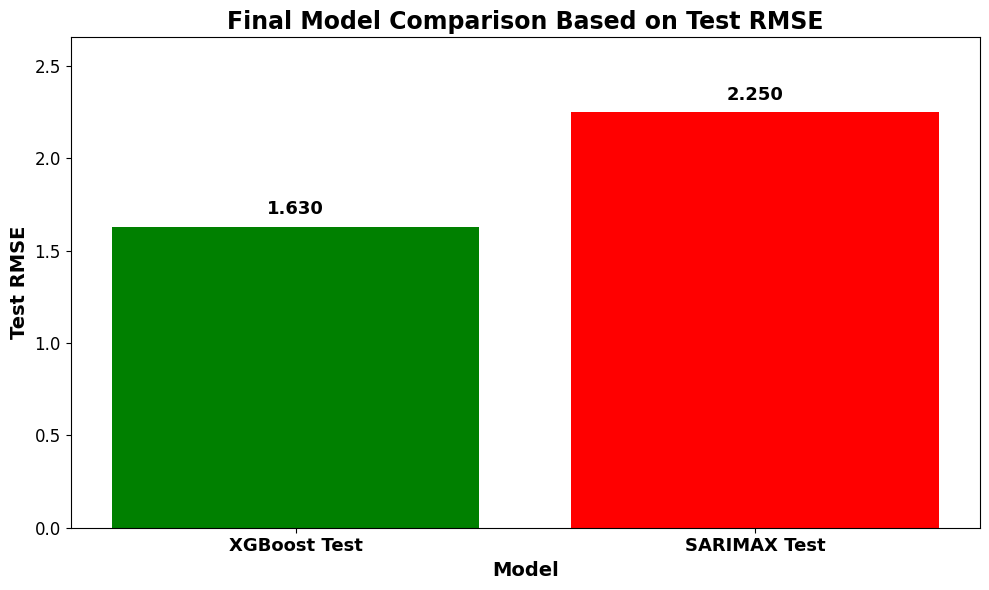

In [228]:
# 9.2 Visual comparison of SARIMAX and XGBoost using test RMSE.
# Lower RMSE means the model has lower forecasting error.
# The best model is highlighted in green, while the weaker model is shown in red.

plot_df = final_model_comparison_df.copy()
best_model = plot_df.loc[plot_df["RMSE"].idxmin(), "model"]

colors = ["green" if model == best_model else "red" for model in plot_df["model"]]

plt.figure(figsize=(10, 6))

bars = plt.bar(
    plot_df["model"],
    plot_df["RMSE"],
    color=colors
)

plt.title("Final Model Comparison Based on Test RMSE", fontsize=17, fontweight="bold")
plt.xlabel("Model", fontsize=14, fontweight="bold")
plt.ylabel("Test RMSE", fontsize=14, fontweight="bold")

plt.xticks(fontsize=13, fontweight="bold")
plt.yticks(fontsize=12)

# Remove grid lines completely for a cleaner chart.
plt.grid(False)

# Add extra space above the tallest bar so the value label does not touch the edge.
plt.ylim(0, plot_df["RMSE"].max() * 1.18)

# Show RMSE value on top of each bar.
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (plot_df["RMSE"].max() * 0.02),
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [229]:
# 9.3 In this cell, we select the final model based on test RMSE.
# The comparison table is already sorted by RMSE, so the first row is the best model.
# This selected model will be used for forecasting coal prices from Jan 2026 to Jun 2026.

best_final_model_df = final_model_comparison_df.head(1).copy()

# Extract the selected model name for later use in the forecasting section.
selected_model_name = best_final_model_df.loc[0, "model"]

print("Selected Final Model:", selected_model_name)

best_final_model_df

Selected Final Model: XGBoost Test


,model,MAE,RMSE,MAPE (%),R2 Score
0,XGBoost Test,1.27,1.63,1.21,0.93


# **10. Forecasting Coal Prices for Jan–Jun 2026**

In [230]:
# 10.1 Prepare forecast input data for Jan 2026 to Jun 2026.
# X_forecast is used for model prediction, so it contains only model feature columns.
# forecast_preview_df is only for checking, so we include Date and actual coal price there.

X_forecast = forecast_model_df[X_train.columns].copy()

forecast_preview_df = pd.concat(
    [
        forecast_model_df[["Date", "newcastle_coal_price"]].reset_index(drop=True),
        X_forecast.reset_index(drop=True)
    ],
    axis=1
)

print("Selected final model:", selected_model_name)
print("X_forecast shape:", X_forecast.shape)
print("Forecast period:", forecast_model_df["Date"].min(), "to", forecast_model_df["Date"].max())

print("\nX_forecast columns used for prediction:")
display(X_forecast.head())

print("\nPreview with Date and actual Newcastle coal price:")
display(forecast_preview_df.head())

Selected final model: XGBoost Test
X_forecast shape: (120, 14)
Forecast period: 2026-01-02 00:00:00 to 2026-06-19 00:00:00

X_forecast columns used for prediction:


,brent_oil_price,natural_gas_price,usd_index_price,baltic_dry_index_price,aud_usd_price,carbon_emissions_price,jkm_lng_price,iron_ore_price,year,month,quarter,coal_lag_1,coal_lag_7,coal_lag_30
2835,60.75,3.618,98.42,1882.0,66.94,86.65,9.700,107.17,2026,1,1,107.50,108.25,111.00
2836,61.76,3.523,98.27,1851.0,67.15,85.60,9.540,106.13,2026,1,1,106.55,108.25,111.00
2837,60.70,3.350,98.58,1830.0,67.37,86.45,9.575,106.79,2026,1,1,106.20,108.25,110.90
2838,59.96,3.525,98.68,1776.0,67.21,86.49,9.605,108.48,2026,1,1,107.25,109.05,111.15
2839,61.99,3.407,98.93,1718.0,67.00,86.53,9.555,107.65,2026,1,1,106.90,107.95,111.15



Preview with Date and actual Newcastle coal price:


,Date,newcastle_coal_price,brent_oil_price,natural_gas_price,usd_index_price,baltic_dry_index_price,aud_usd_price,carbon_emissions_price,jkm_lng_price,iron_ore_price,year,month,quarter,coal_lag_1,coal_lag_7,coal_lag_30
0,2026-01-02,106.55,60.75,3.618,98.42,1882.0,66.94,86.65,9.700,107.17,2026,1,1,107.50,108.25,111.00
1,2026-01-05,106.20,61.76,3.523,98.27,1851.0,67.15,85.60,9.540,106.13,2026,1,1,106.55,108.25,111.00
2,2026-01-06,107.25,60.70,3.350,98.58,1830.0,67.37,86.45,9.575,106.79,2026,1,1,106.20,108.25,110.90
3,2026-01-07,106.90,59.96,3.525,98.68,1776.0,67.21,86.49,9.605,108.48,2026,1,1,107.25,109.05,111.15
4,2026-01-08,107.40,61.99,3.407,98.93,1718.0,67.00,86.53,9.555,107.65,2026,1,1,106.90,107.95,111.15


In [231]:
# 10.2 Generate coal price forecast for Jan 2026 to Jun 2026.
# Here we use the final selected XGBoost model for prediction.

forecast_predictions = final_xgb_model.predict(X_forecast)

# Create daily forecast output table with Date and forecasted coal price.

forecast_output_df = forecast_model_df[["Date"]].copy()

forecast_output_df["forecasted_coal_price"] = forecast_predictions
forecast_output_df["selected_model"] = selected_model_name

# Converting forecasted price to float64 and round it to 2 decimals.

forecast_output_df["forecasted_coal_price"] = (
    forecast_output_df["forecasted_coal_price"]
    .astype("float64")
    .round(2)
)

print("Daily forecast output shape:", forecast_output_df.shape)
print("Forecast period:", forecast_output_df["Date"].min(), "to", forecast_output_df["Date"].max())

forecast_output_df.head()

Daily forecast output shape: (120, 3)
Forecast period: 2026-01-02 00:00:00 to 2026-06-19 00:00:00


,Date,forecasted_coal_price,selected_model
2835,2026-01-02,109.86,XGBoost Test
2836,2026-01-05,107.41,XGBoost Test
2837,2026-01-06,107.41,XGBoost Test
2838,2026-01-07,107.41,XGBoost Test
2839,2026-01-08,107.41,XGBoost Test


In [232]:
# 10.3 Create daily forecast result table.
# This table keeps actual coal price and forecasted coal price together.

forecast_comparison_df = forecast_output_df.merge(
    forecast_model_df[["Date", "newcastle_coal_price"]],
    on="Date",
    how="left"
)

# Rename actual coal price column for clear understanding.

forecast_comparison_df = forecast_comparison_df.rename(
    columns={"newcastle_coal_price": "actual_coal_price"}
)

# Keep only the required columns.

forecast_comparison_df = forecast_comparison_df[
    [
        "Date",
        "actual_coal_price",
        "forecasted_coal_price",
        "selected_model"
    ]
]

print("Forecast comparison table shape:", forecast_comparison_df.shape)

forecast_comparison_df.head()

Forecast comparison table shape: (120, 4)


,Date,actual_coal_price,forecasted_coal_price,selected_model
0,2026-01-02,106.55,109.86,XGBoost Test
1,2026-01-05,106.20,107.41,XGBoost Test
2,2026-01-06,107.25,107.41,XGBoost Test
3,2026-01-07,106.90,107.41,XGBoost Test
4,2026-01-08,107.40,107.41,XGBoost Test


In [233]:
# 10.4 Create monthly forecast summary
# The assignment needs coal price forecast from Jan 2026 to Jun 2026.
# Since we have daily forecast values, we convert them into monthly average values.

monthly_forecast_df = forecast_comparison_df.copy()

# Create month column from Date.
# Example: 2026-01-02 will become 2026-01

monthly_forecast_df["forecast_month"] = monthly_forecast_df["Date"].dt.to_period("M").astype(str)

# Calculate monthly average actual price and forecasted price.

monthly_forecast_df = monthly_forecast_df.groupby("forecast_month").agg(
    actual_monthly_avg_coal_price=("actual_coal_price", "mean"),
    forecasted_monthly_avg_coal_price=("forecasted_coal_price", "mean"),
    selected_model=("selected_model", "first")
).reset_index()

# Round up the value

monthly_forecast_df["actual_monthly_avg_coal_price"] = (
    monthly_forecast_df["actual_monthly_avg_coal_price"].round(2)
)

monthly_forecast_df["forecasted_monthly_avg_coal_price"] = (
    monthly_forecast_df["forecasted_monthly_avg_coal_price"].round(2)
)

print("Monthly forecast summary shape:", monthly_forecast_df.shape)

monthly_forecast_df

Monthly forecast summary shape: (6, 4)


,forecast_month,actual_monthly_avg_coal_price,forecasted_monthly_avg_coal_price,selected_model
0,2026-01,108.27,109.20,XGBoost Test
1,2026-02,116.01,116.54,XGBoost Test
2,2026-03,134.63,136.71,XGBoost Test
3,2026-04,134.47,134.77,XGBoost Test
4,2026-05,132.24,132.32,XGBoost Test
5,2026-06,146.69,145.02,XGBoost Test


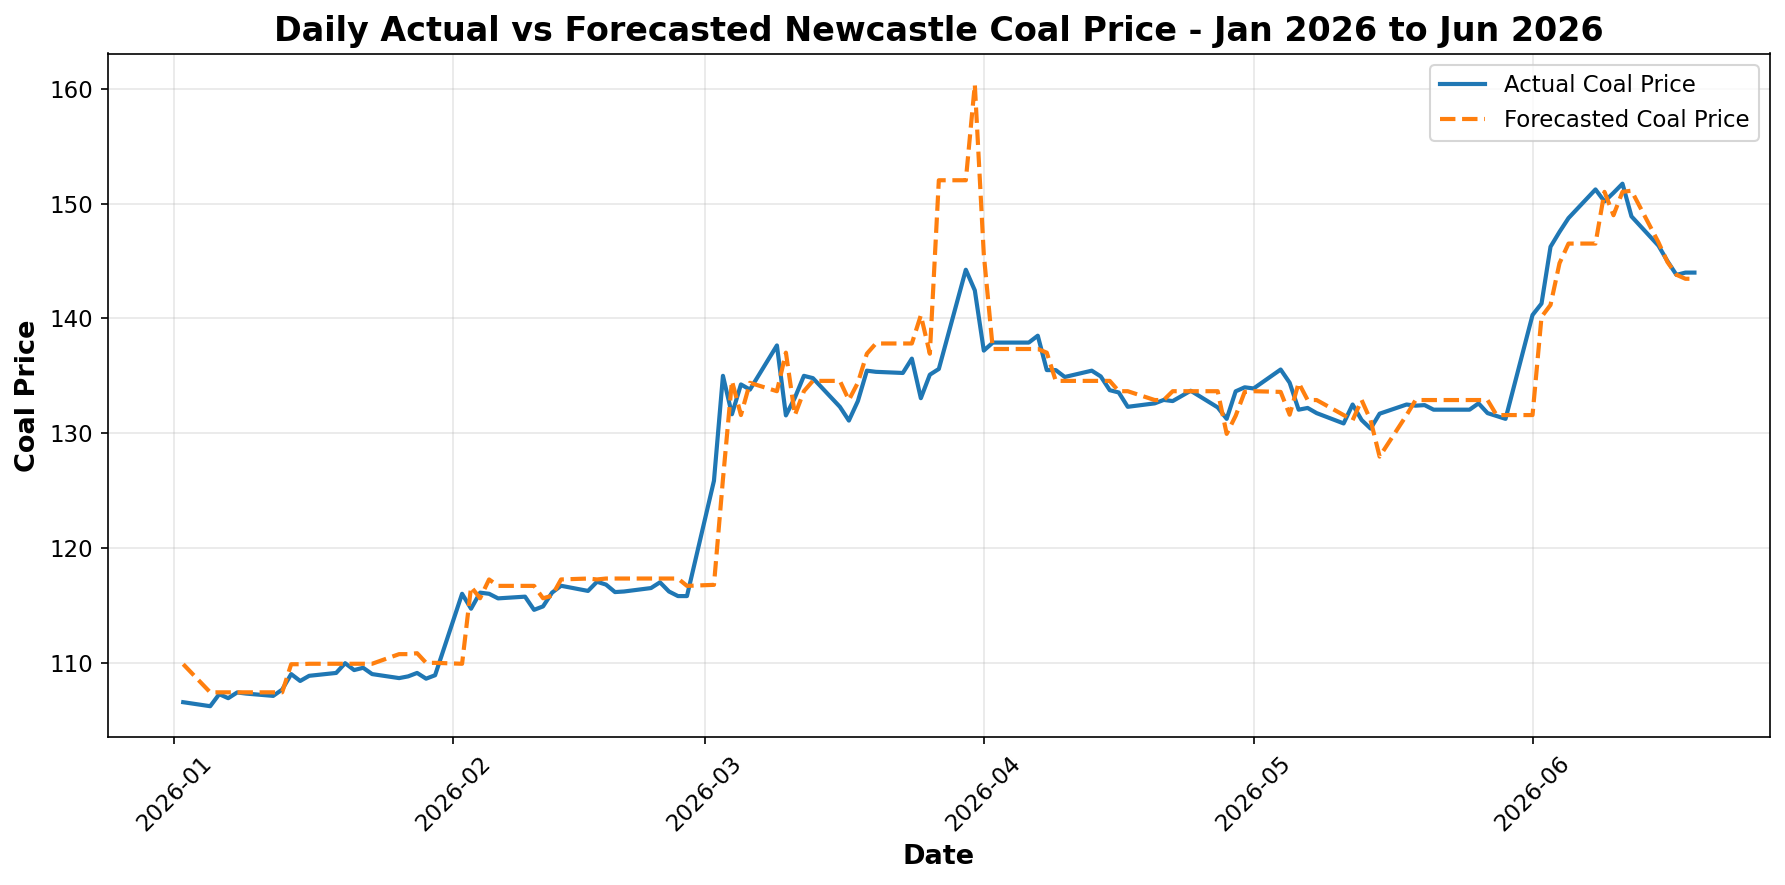

In [234]:
# 10.5 Daily actual vs forecasted coal price chart
# This chart shows day-by-day actual and forecasted coal price movement.

daily_plot_df = forecast_comparison_df.copy()

# Make sure Date is in proper datetime format for plotting.
daily_plot_df["Date"] = pd.to_datetime(daily_plot_df["Date"])

plt.figure(figsize=(12, 6), dpi=150)

plt.plot(
    daily_plot_df["Date"],
    daily_plot_df["actual_coal_price"],
    linewidth=2,
    label="Actual Coal Price"
)

plt.plot(
    daily_plot_df["Date"],
    daily_plot_df["forecasted_coal_price"],
    linewidth=2,
    linestyle="--",
    label="Forecasted Coal Price"
)

plt.title(
    "Daily Actual vs Forecasted Newcastle Coal Price - Jan 2026 to Jun 2026",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date", fontsize=13, fontweight="bold")
plt.ylabel("Coal Price", fontsize=13, fontweight="bold")

plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

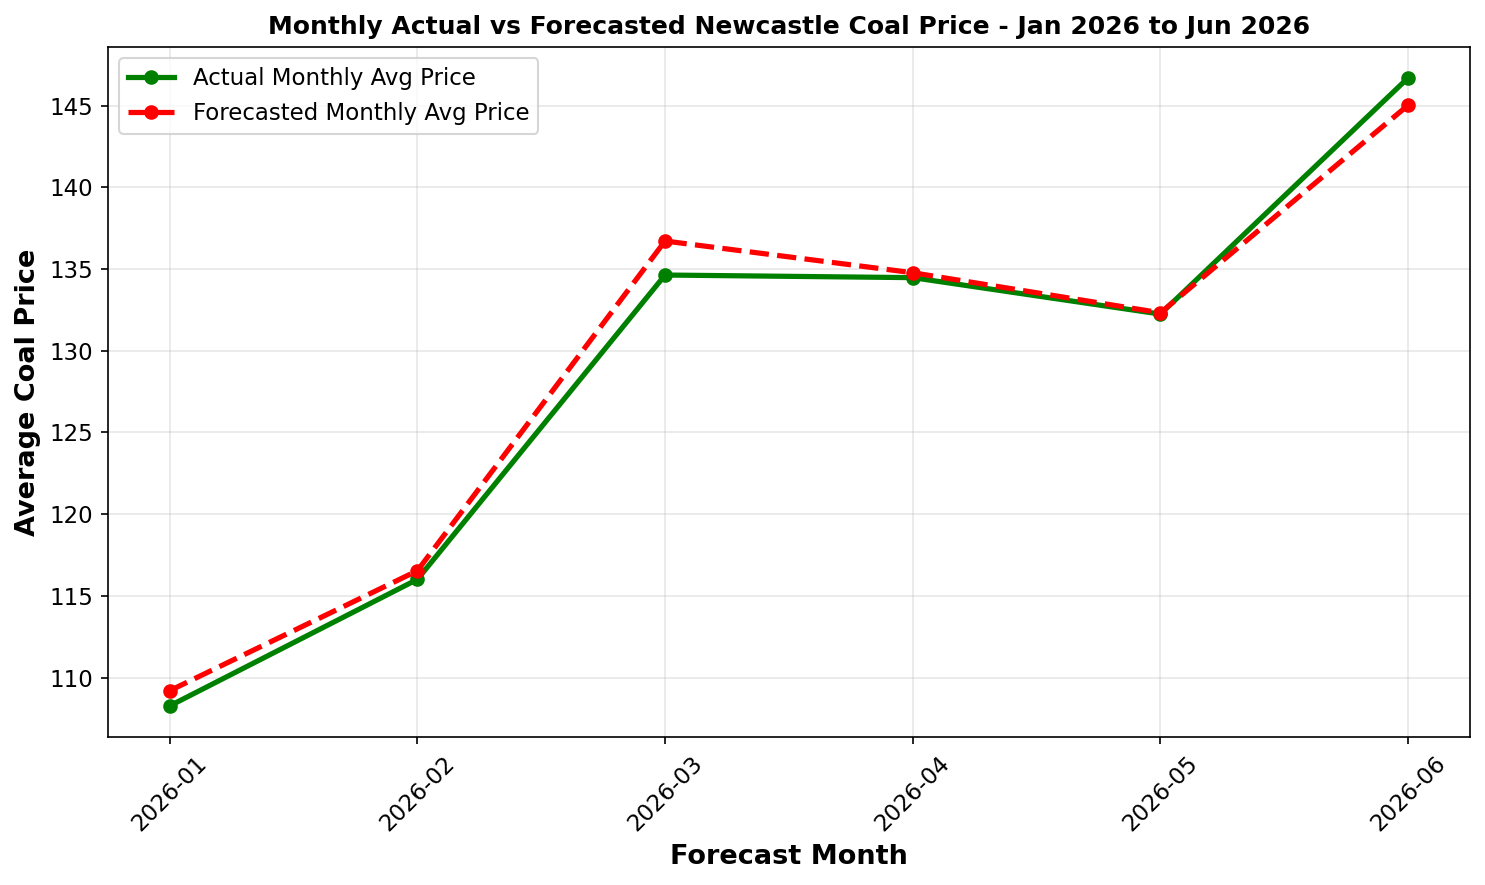

In [235]:
# 10.6 Monthly actual vs forecasted coal price chart
# This chart gives a clean month-wise summary for report and presentation.

monthly_plot_df = monthly_forecast_df.copy()

plt.figure(figsize=(10, 6), dpi=150)

plt.plot(
    monthly_plot_df["forecast_month"],
    monthly_plot_df["actual_monthly_avg_coal_price"],
    marker="o",
    linewidth=2.5,
    color="green",
    label="Actual Monthly Avg Price"
)

plt.plot(
    monthly_plot_df["forecast_month"],
    monthly_plot_df["forecasted_monthly_avg_coal_price"],
    marker="o",
    linewidth=2.5,
    linestyle="--",
    color="red",
    label="Forecasted Monthly Avg Price"
)

plt.title(
    "Monthly Actual vs Forecasted Newcastle Coal Price - Jan 2026 to Jun 2026",
    fontsize=12,
    fontweight="bold"
)

plt.xlabel("Forecast Month", fontsize=13, fontweight="bold")
plt.ylabel("Average Coal Price", fontsize=13, fontweight="bold")

plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [236]:
# 10.7 Creating final forecast output table
# This table includes:
# 1. Daily actual and forecasted Newcastle coal price
# 2. Monthly average actual and forecasted Newcastle coal price
# 3. Input variables used by the model

daily_output_df = forecast_comparison_df.copy()
monthly_output_df = monthly_forecast_df.copy()
input_variables_df = X_forecast.copy()

# Create month column in daily data.
# This helps us attach the correct monthly average value to each daily row.

daily_output_df["forecast_month"] = (
    daily_output_df["Date"].dt.to_period("M").astype(str)
)

# Rename daily columns clearly.

daily_output_df = daily_output_df.rename(
    columns={
        "Date": "daily_date",
        "actual_coal_price": "daily_actual_newcastle_coal_price",
        "forecasted_coal_price": "daily_forecasted_newcastle_coal_price",
        "selected_model": "daily_selected_model"
    }
)

# Rename monthly columns clearly.

monthly_output_df = monthly_output_df.rename(
    columns={
        "actual_monthly_avg_coal_price": "monthly_actual_avg_newcastle_coal_price",
        "forecasted_monthly_avg_coal_price": "monthly_forecasted_avg_newcastle_coal_price",
        "selected_model": "monthly_selected_model"
    }
)

# Merge monthly summary into daily data using forecast_month.
# Now every daily row will show the monthly average value for its month.

final_forecast_output_df = daily_output_df.merge(
    monthly_output_df,
    on="forecast_month",
    how="left"
)

# Add input variables used by the model.
# Prefix is added so these columns are easy to identify.

input_variables_df = input_variables_df.add_prefix("input_")

final_forecast_output_df = pd.concat(
    [
        final_forecast_output_df.reset_index(drop=True),
        input_variables_df.reset_index(drop=True)
    ],
    axis=1
)

print("Final forecast output shape:", final_forecast_output_df.shape)

final_forecast_output_df.head(10)

Final forecast output shape: (120, 22)


,daily_date,daily_actual_newcastle_coal_price,daily_forecasted_newcastle_coal_price,daily_selected_model,forecast_month,monthly_actual_avg_newcastle_coal_price,monthly_forecasted_avg_newcastle_coal_price,monthly_selected_model,input_brent_oil_price,input_natural_gas_price,...,input_aud_usd_price,input_carbon_emissions_price,input_jkm_lng_price,input_iron_ore_price,input_year,input_month,input_quarter,input_coal_lag_1,input_coal_lag_7,input_coal_lag_30
0,2026-01-02,106.55,109.86,XGBoost Test,2026-01,108.27,109.2,XGBoost Test,60.75,3.618,...,66.94,86.65,9.700,107.17,2026,1,1,107.50,108.25,111.00
1,2026-01-05,106.20,107.41,XGBoost Test,2026-01,108.27,109.2,XGBoost Test,61.76,3.523,...,67.15,85.60,9.540,106.13,2026,1,1,106.55,108.25,111.00
2,2026-01-06,107.25,107.41,XGBoost Test,2026-01,108.27,109.2,XGBoost Test,60.70,3.350,...,67.37,86.45,9.575,106.79,2026,1,1,106.20,108.25,110.90
3,2026-01-07,106.90,107.41,XGBoost Test,2026-01,108.27,109.2,XGBoost Test,59.96,3.525,...,67.21,86.49,9.605,108.48,2026,1,1,107.25,109.05,111.15
4,2026-01-08,107.40,107.41,XGBoost Test,2026-01,108.27,109.2,XGBoost Test,61.99,3.407,...,67.00,86.53,9.555,107.65,2026,1,1,106.90,107.95,111.15
5,2026-01-09,107.30,107.41,XGBoost Test,2026-01,108.27,109.2,XGBoost Test,63.34,3.169,...,66.87,87.89,9.565,108.03,2026,1,1,107.40,106.65,111.15
6,2026-01-12,107.10,107.41,XGBoost Test,2026-01,108.27,109.2,XGBoost Test,63.87,3.409,...,67.11,88.44,9.610,108.25,2026,1,1,107.30,107.50,111.00
7,2026-01-13,107.65,107.41,XGBoost Test,2026-01,108.27,109.2,XGBoost Test,65.47,3.419,...,66.82,89.08,9.610,107.90,2026,1,1,107.10,106.55,111.10
8,2026-01-14,109.00,109.86,XGBoost Test,2026-01,108.27,109.2,XGBoost Test,66.52,3.120,...,66.82,90.15,9.595,107.68,2026,1,1,107.65,106.20,108.35
9,2026-01-15,108.40,109.86,XGBoost Test,2026-01,108.27,109.2,XGBoost Test,63.76,3.128,...,66.99,90.56,9.610,107.39,2026,1,1,109.00,107.25,108.80


In [237]:
# 10.8 Save final forecast output as one CSV file
# This CSV will be used as the final forecast output dataset.

final_forecast_path = FORECAST_OUTPUT_PATH / "final_newcastle_coal_price_forecast_jan_jun_2026.csv"

final_forecast_output_df.to_csv(final_forecast_path, index=False)

print("Final forecast CSV saved at:")
print(final_forecast_path)

Final forecast CSV saved at:
/content/drive/MyDrive/forecast_outputs/final_newcastle_coal_price_forecast_jan_jun_2026.csv
